In [1]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from vivarium import Artifact, InteractiveContext
import pandas as pd, numpy as np, os

In [2]:
!whoami
!date

zmbc
Thu May 14 15:21:01 PDT 2026


# V&V neonatal mortality in an interactive simulation

General approach:
* Check quantities subject to stochastic uncertainty both visually and with a statistical test
* Single draw, location, and scenario (baseline)
* Only test relative to artifact, because GBD shared functions can't be directly used in the sim environment -- **this notebook will not find issues in artifact creation**

In [3]:
%pip list | grep vivarium

vivarium                                 4.0.2
vivarium_build_utils                     2.3.8
vivarium_cluster_tools                   3.0.0
vivarium_dependencies                    1.0.7
vivarium_gates_mncnh                     33.1.dev3+gfb9a80fb8 /mnt/share/homes/zmbc/src/vivarium_gates_mncnh
vivarium_public_health                   5.0.1
vivarium_testing_utils                   0.5.1
Note: you may need to restart the kernel to use updated packages.


In [4]:
%pip freeze | grep vivarium

vivarium==4.0.2
vivarium_build_utils==2.3.8
vivarium_cluster_tools==3.0.0
vivarium_dependencies==1.0.7
-e git+https://github.com/ihmeuw/vivarium_gates_mncnh.git@fb9a80fb8aa5e421fabff4e89d1278c8c89c18cf#egg=vivarium_gates_mncnh
vivarium_public_health==5.0.1
vivarium_testing_utils==0.5.1
Note: you may need to restart the kernel to use updated packages.


In [5]:
! cat /mnt/share/homes/zmbc/src/vivarium_gates_mncnh/.git/HEAD

ref: refs/heads/neonatal_mortality_vv


In [6]:
draw_num = 60

In [7]:
from pathlib import Path

In [8]:
import vivarium_gates_mncnh
from vivarium.framework.configuration import build_model_specification

main_sim_model_specification = build_model_specification(
    Path(vivarium_gates_mncnh.__file__).parent / 'model_specifications/model_spec.yaml'
)
del main_sim_model_specification.configuration.observers
main_sim_model_specification.configuration.input_data.input_draw_number = draw_num
main_sim_model_specification.configuration.population.population_size = 10_000_000

In [9]:
paf_sim_model_specification = build_model_specification(
    Path(vivarium_gates_mncnh.__file__).parent / 'data/lbwsg_paf/code/lbwsg_paf.yaml'
)
# Don't delete observers since we use these to get the PAFs
paf_sim_model_specification.configuration.input_data.input_draw_number = draw_num
paf_sim_model_specification.configuration.population.population_size = (
    400**2 # 400x400 grid on gestational age and birth weight...
    * 58 # ... in each LBWSG category
    * 2 # ... for each sex
)

In [10]:
location = "Ethiopia"

In [11]:
orig_location = Path(main_sim_model_specification.configuration.input_data.artifact_path).stem
assert orig_location == Path(paf_sim_model_specification.configuration.input_data.artifact_path).stem
orig_location

'ethiopia'

In [12]:
main_sim_model_specification.configuration.input_data.artifact_path = main_sim_model_specification.configuration.input_data.artifact_path.replace(orig_location, location.lower())
assert Path(main_sim_model_specification.configuration.input_data.artifact_path).stem == location.lower()
paf_sim_model_specification.configuration.input_data.artifact_path = paf_sim_model_specification.configuration.input_data.artifact_path.replace(orig_location, location.lower())
assert Path(paf_sim_model_specification.configuration.input_data.artifact_path).stem == location.lower()

In [13]:
art = Artifact(main_sim_model_specification.configuration.input_data.artifact_path)

## Create simulations

In [14]:
%%time

main_sim = InteractiveContext(main_sim_model_specification)

2026-05-14 15:21:07.848 | INFO     | simulation_1-artifact_manager:80 - Running simulation from artifact located at /mnt/team/simulation_science/pub/models/vivarium_gates_mncnh/artifacts/model33.0/ethiopia.hdf.
2026-05-14 15:21:07.849 | INFO     | simulation_1-artifact_manager:81 - Artifact base filter terms are ['draw == 60'].
2026-05-14 15:21:07.850 | INFO     | simulation_1-artifact_manager:82 - Artifact additional filter terms are None.
2026-05-14 15:21:36.244 | WARNING  | simulation_1-results_manager:409 - Specified excluded stratifications are already not included by default: ['stillbirth', 'partial_term']
2026-05-14 15:21:36.247 | WARNING  | simulation_1-results_manager:409 - Specified excluded stratifications are already not included by default: ['stillbirth', 'partial_term']
2026-05-14 15:21:36.349 | WARNING  | simulation_1-lookup_table_manager:85 - Component 'risk_factor.hemoglobin' configured, but didn't build lookup table 'exposure' during setup.
2026-05-14 15:21:36.350 | W

In [15]:
main_sim_components = main_sim.list_components()
list(main_sim_components.keys())

['risk_factor.hemoglobin',
 'anemia_intervention_propensity',
 'ageless_population.population.scaling_factor',
 'pregnancy',
 'new_children',
 'results_stratifier',
 'anc_attendance',
 'ultrasound',
 'maternal_disorder.maternal_obstructed_labor_and_uterine_rupture',
 'maternal_disorder.maternal_hemorrhage',
 'maternal_disorder.maternal_sepsis_and_other_maternal_infections',
 'residual_maternal_disorders',
 'abortion_miscarriage_ectopic_pregnancy',
 'maternal_disorders_burden',
 'risk_factor.low_birth_weight_and_short_gestation',
 'risk_effect.low_birth_weight_and_short_gestation_on_cause.all_causes.all_cause_mortality_risk',
 'risk_effect.low_birth_weight_and_short_gestation_on_cause.neonatal_sepsis_and_other_neonatal_infections.cause_specific_mortality_risk',
 'risk_effect.low_birth_weight_and_short_gestation_on_cause.neonatal_preterm_birth_with_rds.cause_specific_mortality_risk',
 'risk_effect.low_birth_weight_and_short_gestation_on_cause.neonatal_preterm_birth_without_rds.cause_spec

In [16]:
%%time

paf_sim = InteractiveContext(paf_sim_model_specification)

2026-05-14 15:32:58.493 | INFO     | simulation_2-artifact_manager:80 - Running simulation from artifact located at /mnt/team/simulation_science/pub/models/vivarium_gates_mncnh/artifacts/model28.1/ethiopia.hdf.
2026-05-14 15:32:58.495 | INFO     | simulation_2-artifact_manager:81 - Artifact base filter terms are ['draw == 60'].
2026-05-14 15:32:58.496 | INFO     | simulation_2-artifact_manager:82 - Artifact additional filter terms are None.
2026-05-14 15:33:02.405 | WARNING  | simulation_2-lookup_table_manager:85 - Component 'risk_factor.low_birth_weight_and_short_gestation' configured, but didn't build lookup table 'exposure' during setup.
2026-05-14 15:33:02.406 | WARNING  | simulation_2-lookup_table_manager:85 - Component 'risk_factor.low_birth_weight_and_short_gestation' configured, but didn't build lookup table 'ensemble_distribution_weights' during setup.
2026-05-14 15:33:02.407 | WARNING  | simulation_2-lookup_table_manager:85 - Component 'risk_factor.low_birth_weight_and_short_

In [17]:
paf_sim_components = paf_sim.list_components()
list(paf_sim_components.keys())

['paf_results_stratifier',
 'evenly_distributed_population',
 'lbwsg_mortality',
 'risk_factor.low_birth_weight_and_short_gestation',
 'risk_effect.low_birth_weight_and_short_gestation_on_cause.all_causes.all_cause_mortality_risk',
 'lbwsgpaf_observer.cause.all_causes.all_cause_mortality_risk',
 'preterm_prevalence_observer']

## ENN mortality

### Step main sim to ENN mortality

In [18]:
get_event_name = main_sim._builder.time.simulation_event_name()
get_event_name()

'first_trimester_anc'

In [19]:
%%time

while get_event_name() != 'early_neonatal_mortality':
    main_sim.step()
    print(get_event_name())

2026-05-14 16:09:48.805 | INFO     | simulation_1 - vivarium.framework.engine:280 - 2025-01-01 00:00:00
later_pregnancy_screening
2026-05-14 16:23:40.320 | INFO     | simulation_1 - vivarium.framework.engine:280 - 2025-01-02 00:00:00
later_pregnancy_intervention
2026-05-14 16:26:34.227 | INFO     | simulation_1 - vivarium.framework.engine:280 - 2025-01-03 00:00:00
later_pregnancy_visit_timing
2026-05-14 16:30:52.161 | INFO     | simulation_1 - vivarium.framework.engine:280 - 2025-01-04 00:00:00
ultrasound
2026-05-14 16:40:21.496 | INFO     | simulation_1 - vivarium.framework.engine:280 - 2025-01-05 00:00:00
delivery_facility
2026-05-14 16:54:14.974 | INFO     | simulation_1 - vivarium.framework.engine:280 - 2025-01-06 00:00:00
azithromycin_access
2026-05-14 16:56:15.615 | INFO     | simulation_1 - vivarium.framework.engine:280 - 2025-01-07 00:00:00
misoprostol_access
2026-05-14 16:58:14.821 | INFO     | simulation_1 - vivarium.framework.engine:280 - 2025-01-08 00:00:00
cpap_access
2026

In [20]:
assert get_event_name() == 'early_neonatal_mortality'

### Check that PAF sim is in ENN

In [21]:
from vivarium_gates_mncnh.constants.data_values import LATE_NEONATAL_AGE_START, LATE_NEONATAL_AGE_END

assert (paf_sim.get_population(["child_age"]).child_age < LATE_NEONATAL_AGE_START).all()

### Transfer PAFs and preterm prevalence to main sim

In [22]:
from vivarium.framework.event import Event

In [23]:
paf_sim._results.gather_results(Event(
    "time_step",
    index=paf_sim.get_population_index(),
    user_data={},
    time=paf_sim._clock.time,
    step_size=paf_sim._clock.step_size,
))

In [24]:
def process_pafs(pafs):
    pafs = pafs.rename(columns={"child_sex": "sex_of_child"})
    pafs["child_age_start"] = pafs["child_age_group"].map({
        "early_neonatal": 0,
        "late_neonatal": LATE_NEONATAL_AGE_START,
    })
    pafs["child_age_end"] = pafs["child_age_group"].map({
        "early_neonatal": LATE_NEONATAL_AGE_START,
        "late_neonatal": LATE_NEONATAL_AGE_END,
    })
    pafs["year_start"] = 2021
    pafs["year_end"] = 2022

    return pafs.drop(columns=["child_age_group"])

In [25]:
acmrisk_pafs = process_pafs(
    paf_sim.get_results()['calculated_lbwsg_paf_on_cause.all_causes.all_cause_mortality_risk']
)
acmrisk_pafs

,sex_of_child,value,child_age_start,child_age_end,year_start,year_end
0,Female,0.823918,0.000000,0.019178,2021,2022
1,Male,0.847904,0.000000,0.019178,2021,2022
2,Female,0.000000,0.019178,0.076712,2021,2022
3,Male,0.000000,0.019178,0.076712,2021,2022


In [26]:
preterm_csmr_pafs = process_pafs(
    paf_sim.get_results()['calculated_lbwsg_paf_on_cause.all_causes.all_cause_mortality_risk_preterm']
)
preterm_csmr_pafs

,sex_of_child,value,child_age_start,child_age_end,year_start,year_end
0,Female,0.957253,0.000000,0.019178,2021,2022
1,Male,0.951496,0.000000,0.019178,2021,2022
2,Female,0.000000,0.019178,0.076712,2021,2022
3,Male,0.000000,0.019178,0.076712,2021,2022


In [27]:
import vivarium

def update_lookup_table(lookup_table, new_data):
    # NOTE: When we get to Vivarium 4.1 we can just call lookup_table.set_data(new_data)
    lookup_table.data = new_data
    # https://github.com/ihmeuw/vivarium/blob/c4d88f7c76df9650f426c43fd44131d5bb272709/src/vivarium/framework/lookup/table.py#L93-L115
    parameter_columns_with_edges: list[tuple[str, str, str]] = [
        (p, f"{p}_start", f"{p}_end") for p in lookup_table.parameter_columns
    ]

    lookup_table.interpolation = vivarium.framework.lookup.table.Interpolation(
        lookup_table.data,
        lookup_table.key_columns,
        parameter_columns_with_edges,
        lookup_table.value_columns,
        order=lookup_table._manager.interpolation_order,
        extrapolate=lookup_table._manager.extrapolate,
        validate=lookup_table._manager.validate_interpolation,
    )

In [28]:
acmr_paf_components = [k for k in main_sim_components if 'risk_effect.low_birth_weight_' in k and 'preterm' not in k]
acmr_paf_components

['risk_effect.low_birth_weight_and_short_gestation_on_cause.all_causes.all_cause_mortality_risk',
 'risk_effect.low_birth_weight_and_short_gestation_on_cause.neonatal_sepsis_and_other_neonatal_infections.cause_specific_mortality_risk',
 'risk_effect.low_birth_weight_and_short_gestation_on_cause.neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma.cause_specific_mortality_risk']

In [29]:
for component in acmr_paf_components:
    update_lookup_table(main_sim_components[component].paf_table, acmrisk_pafs)

In [30]:
preterm_paf_components = [k for k in main_sim_components if ('risk_effect.low_birth_weight_' in k and 'preterm' in k) or ('preterm_birth.' in k)]
preterm_paf_components

['risk_effect.low_birth_weight_and_short_gestation_on_cause.neonatal_preterm_birth_with_rds.cause_specific_mortality_risk',
 'risk_effect.low_birth_weight_and_short_gestation_on_cause.neonatal_preterm_birth_without_rds.cause_specific_mortality_risk',
 'preterm_birth.neonatal_preterm_birth_with_rds',
 'preterm_birth.neonatal_preterm_birth_without_rds']

In [31]:
for component in preterm_paf_components:
    update_lookup_table(main_sim_components[component].paf_table, preterm_csmr_pafs)

### Check all-cause mortality risk

In [32]:
# Check that our transfer above actually worked
assert (
    set(main_sim.get_population("all_causes.all_cause_mortality_risk.paf").unique())
    <=
    set(acmrisk_pafs['value'].unique())
)

In [33]:
# https://github.com/ihmeuw/vivarium_gates_mncnh/blob/9502fba51790f522523b8cd2925e539a692babf6/src/vivarium_gates_mncnh/components/mortality.py#L281-L283
pop = main_sim.get_population([
    "child_alive",
    "sex_of_child",
    "pregnancy_outcome",
    "effect_of_low_birth_weight_and_short_gestation_on_early_neonatal_all_causes_relative_risk",
    "effect_of_low_birth_weight_and_short_gestation_on_late_neonatal_all_causes_relative_risk"
])
alive_idx = pop.index[pop['child_alive'] == True]
mortality_risk = main_sim.get_population("death_in_age_group_probability").loc[alive_idx]

In [34]:
def get_acmrisk_targets(age_group_start, age_group_end):
    return (
        art.load('cause.all_causes.all_cause_mortality_risk')[f'draw_{draw_num}'].reset_index()
        .pipe(lambda df: df[(df.age_start == age_group_start) & (df.age_end == age_group_end)])
        .drop(columns=['age_start', 'age_end', 'year_start', 'year_end'])
        .set_index('sex')
        [f'draw_{draw_num}']
    )

In [35]:
enn_acmrisk_targets = get_acmrisk_targets(0, LATE_NEONATAL_AGE_START)
enn_acmrisk_targets

sex
Female    0.014576
Male      0.025991
Name: draw_60, dtype: float64

In [36]:
from vivarium_testing_utils.fuzzy_checker import FuzzyChecker
import matplotlib.pyplot as plt

fuzzy_checker = FuzzyChecker()
any_failures = False

def fuzzy_check(observed_values, targets, name, acceptable_deviation=None):
    global any_failures
    print('Targets')
    display(targets)

    observed_value_summaries = observed_values.groupby(pop.sex_of_child).describe()

    print('Summaries of observed values')
    display(observed_value_summaries)

    # if acceptable_deviation is None:
    #     target_lambda = lambda x: x
    # else:
    #     target_lambda = lambda x: (x * (1 - acceptable_deviation), x * (1 + acceptable_deviation))

    # for sex in ['Female', 'Male']:
    #     try:
    #         fuzzy_checker.fuzzy_assert_mean(
    #             observed_values=observed_values[pop.sex_of_child == sex],
    #             target_mean=target_lambda(targets.loc[sex]),
    #             name=f'{name} by sex',
    #         )
    #     except AssertionError as e:
    #         print(e)
    #         any_failures = True

    # try:
    #     overall_target = (pop.loc[alive_idx].groupby('sex_of_child').size() * targets).sum() / len(alive_idx)
    #     fuzzy_checker.fuzzy_assert_mean(
    #         observed_values=observed_values,
    #         target_mean=target_lambda(overall_target),
    #         name=name,
    #     )
    # except AssertionError as e:
    #     print(e)
    #     any_failures = True

    plt.errorbar(
        targets.loc[observed_value_summaries.index],
        observed_value_summaries['mean'],
        # Frequentist SE for plots
        yerr=observed_value_summaries['std'] / np.sqrt(observed_value_summaries['count']),
        fmt="o",
    )
    max_val = max(targets.loc[observed_value_summaries.index].max(), observed_value_summaries['mean'].max())
    min_val = min(targets.loc[observed_value_summaries.index].min(), observed_value_summaries['mean'].min())
    plt.plot([min_val, max_val], [min_val, max_val], 'k--')
    plt.title(f'{name} by sex')
    plt.xlabel('artifact value')
    plt.ylabel('simulation value')
    plt.show()

    plt.errorbar(
        targets.loc[observed_value_summaries.index],
        observed_value_summaries['mean'] / targets.loc[observed_value_summaries.index],
        # Frequentist SE for plots
        yerr=observed_value_summaries['std'] / np.sqrt(observed_value_summaries['count']) / targets.loc[observed_value_summaries.index],
        fmt="o",
    )
    plt.plot([min_val, max_val], [1, 1], 'k--')
    plt.title(f'{name} by sex relative error')
    plt.xlabel('artifact value')
    plt.ylabel('simulation value / artifact value')
    plt.show()

Targets


sex
Female    0.014576
Male      0.025991
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.014588,0.046118,0.002559,0.002559,0.003082,0.006066,0.818658
Male,2820853.0,0.025571,0.066674,0.003932,0.003954,0.005286,0.012583,0.879008


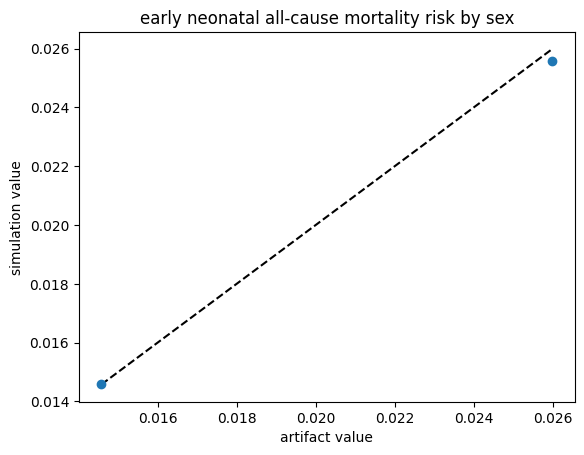

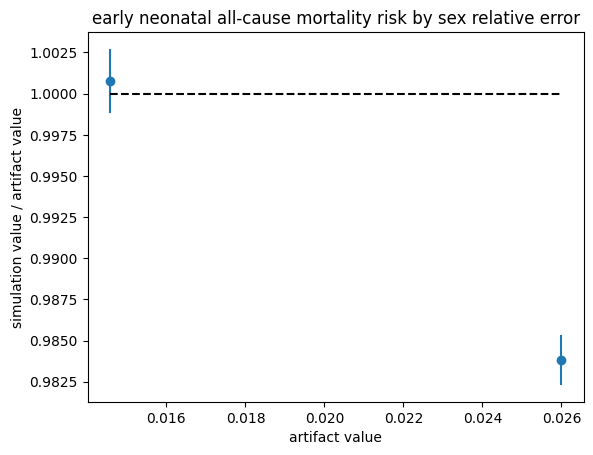

In [37]:
fuzzy_check(mortality_risk, enn_acmrisk_targets, "early neonatal all-cause mortality risk")

#### Check individual steps in calculation of all-cause mortality risk

In [38]:
def step_by_step_check_acmrisk(age_group_start, age_group_end):
    acmrisk_targets = get_acmrisk_targets(age_group_start, age_group_end)
    # https://github.com/ihmeuw/vivarium_gates_mncnh/blob/86f8e36e8f781549cd6671cba9ad33912638dc4a/src/vivarium_gates_mncnh/components/mortality.py#L357-L361
    print('Initial mortality risk')
    initial_all_cause_mortality_risk = main_sim_components['neonatal_mortality'].all_cause_mortality_risk(alive_idx)
    # Does not vary except by sex
    assert (initial_all_cause_mortality_risk.groupby(pop.sex_of_child).nunique() == 1).all()
    # Exactly matches artifact values
    assert np.allclose(initial_all_cause_mortality_risk.groupby(pop.sex_of_child).mean(), acmrisk_targets, rtol=0, atol=1e-14)
    display(initial_all_cause_mortality_risk.groupby(pop.sex_of_child).mean())

    # Next (conceptually) is applying LBWSG PAF and RR
    lbwsg_paf = main_sim_components['risk_effect.low_birth_weight_and_short_gestation_on_cause.all_causes.all_cause_mortality_risk'].paf_table(alive_idx)
    if age_group_start == 0 and age_group_end == LATE_NEONATAL_AGE_START:
        age_group_name = 'early_neonatal'
    elif age_group_start == LATE_NEONATAL_AGE_START and age_group_end == LATE_NEONATAL_AGE_END:
        age_group_name = 'late_neonatal'
    else:
        raise ValueError("Unknown age group")

    lbwsg_rr = pop.loc[alive_idx][f'effect_of_low_birth_weight_and_short_gestation_on_{age_group_name}_all_causes_relative_risk']

    acmrisk_after_lbwsg = initial_all_cause_mortality_risk * (1 - lbwsg_paf) * lbwsg_rr
    print('After LBWSG:')
    display(acmrisk_after_lbwsg.groupby(pop.sex_of_child).describe())

    fuzzy_check(acmrisk_after_lbwsg, acmrisk_targets, "ACMRisk after LBWSG")

    # Check that we've exactly replicated everything up to mutators
    pop_mgr = main_sim._builder.population._manager
    pipeline = pop_mgr._get_attribute_pipelines()["death_in_age_group_probability"]
    assert np.allclose(acmrisk_after_lbwsg, pipeline.source(pop_mgr, alive_idx), rtol=0, atol=1e-14)

    # Now we add in CSMRisk-based modifications
    print('Mutators:')
    display(pipeline.mutators)

    working_acmrisk = acmrisk_after_lbwsg

    for mutator in pipeline.mutators:
        print(f'After {mutator}')
        working_acmrisk = mutator(alive_idx, working_acmrisk)
        # Add acceptable deviation in LNN for CPAP PAF not being age-specific
        acceptable_deviation = 0.01 if age_group_name == 'late_neonatal' else None
        fuzzy_check(working_acmrisk, acmrisk_targets, "ACMRisk after mutator", acceptable_deviation=acceptable_deviation)

    # Check that we've exactly replicated everything
    assert np.allclose(working_acmrisk, pipeline(alive_idx), rtol=0, atol=1e-14)

Initial mortality risk


sex_of_child
Female    0.014576
Male      0.025991
Name: value, dtype: float64

After LBWSG:


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.015411,0.049037,0.002567,0.002567,0.003096,0.006198,0.787392
Male,2820853.0,0.027558,0.071616,0.003953,0.003975,0.005351,0.013113,0.840535


Targets


sex
Female    0.014576
Male      0.025991
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.015411,0.049037,0.002567,0.002567,0.003096,0.006198,0.787392
Male,2820853.0,0.027558,0.071616,0.003953,0.003975,0.005351,0.013113,0.840535


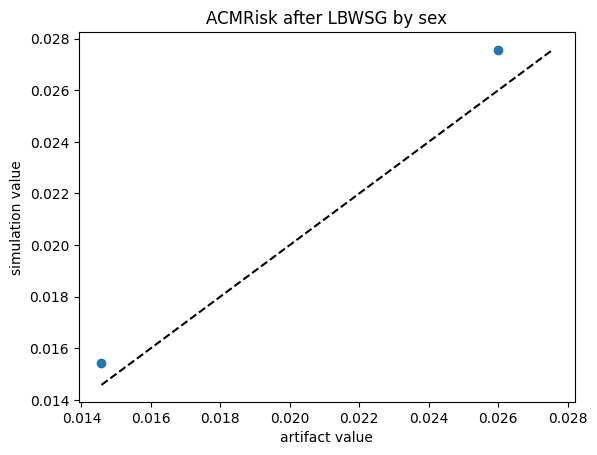

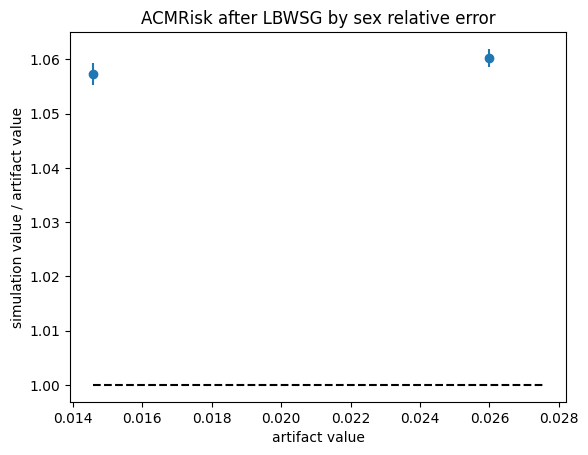

Mutators:


After <vivarium.framework.values.pipeline.ValueModifier object at 0x7f2f68c69950>
Targets


sex
Female    0.014576
Male      0.025991
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.014679,0.046425,0.002567,0.002567,0.003093,0.006092,0.821096
Male,2820853.0,0.025863,0.067393,0.003953,0.003975,0.005318,0.012696,0.883497


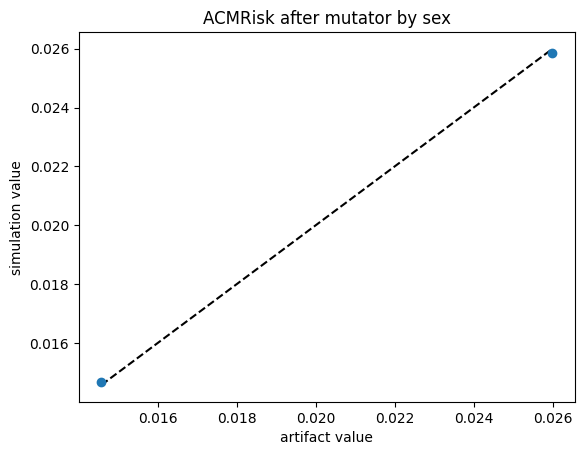

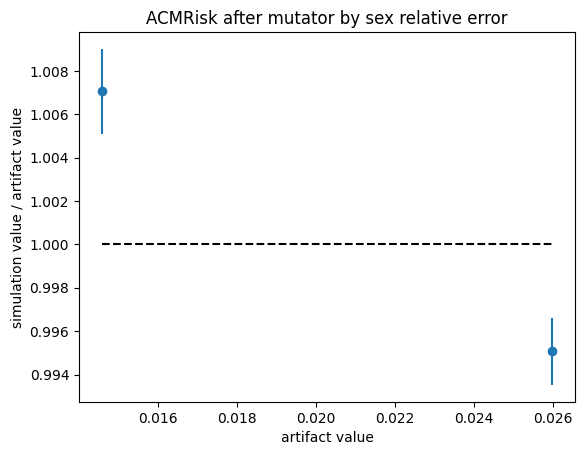

After <vivarium.framework.values.pipeline.ValueModifier object at 0x7f2f68c2d410>
Targets


sex
Female    0.014576
Male      0.025991
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.014679,0.046425,0.002567,0.002567,0.003093,0.006092,0.821096
Male,2820853.0,0.025863,0.067393,0.003953,0.003975,0.005318,0.012696,0.883497


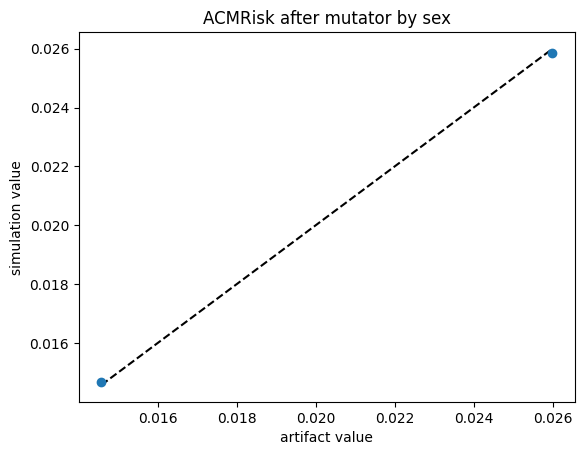

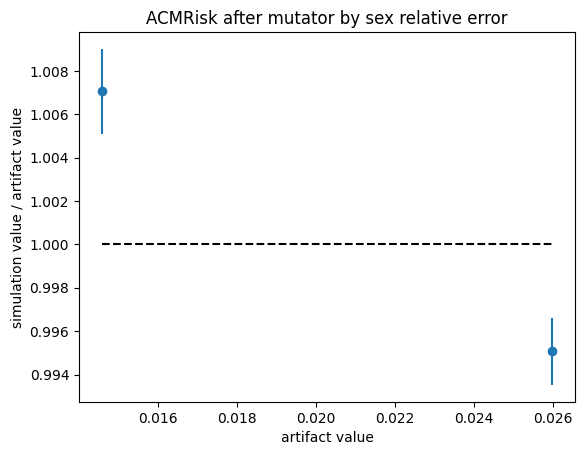

After <vivarium.framework.values.pipeline.ValueModifier object at 0x7f2f68c30e90>
Targets


sex
Female    0.014576
Male      0.025991
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.014588,0.046118,0.002559,0.002559,0.003082,0.006066,0.818658
Male,2820853.0,0.025571,0.066674,0.003932,0.003954,0.005286,0.012583,0.879008


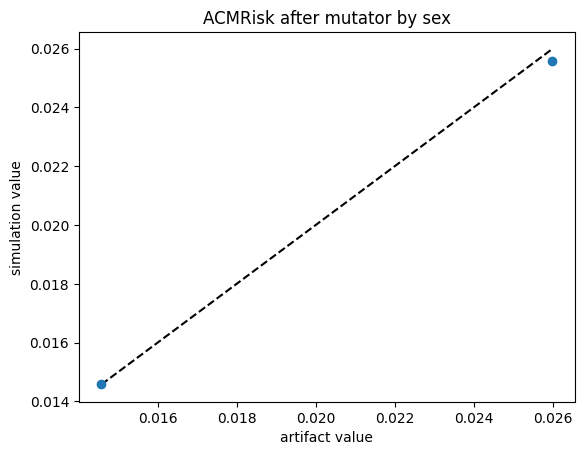

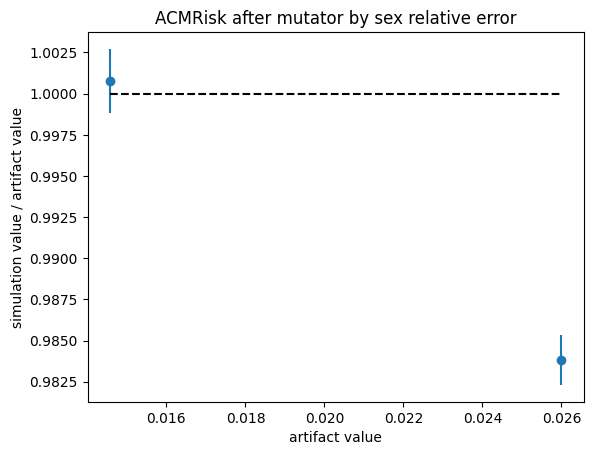

After <vivarium.framework.values.pipeline.ValueModifier object at 0x7f2f68c8cf10>
Targets


sex
Female    0.014576
Male      0.025991
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.014588,0.046118,0.002559,0.002559,0.003082,0.006066,0.818658
Male,2820853.0,0.025571,0.066674,0.003932,0.003954,0.005286,0.012583,0.879008


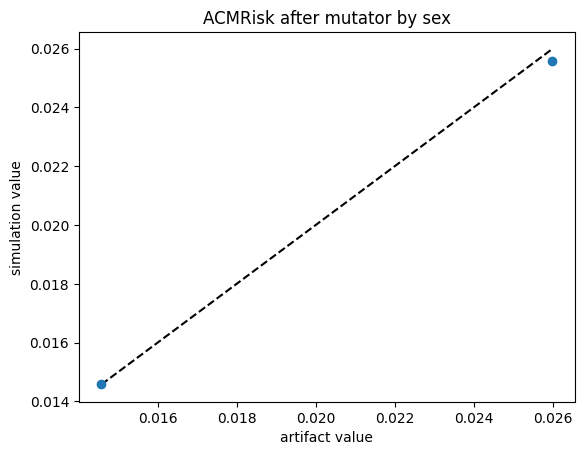

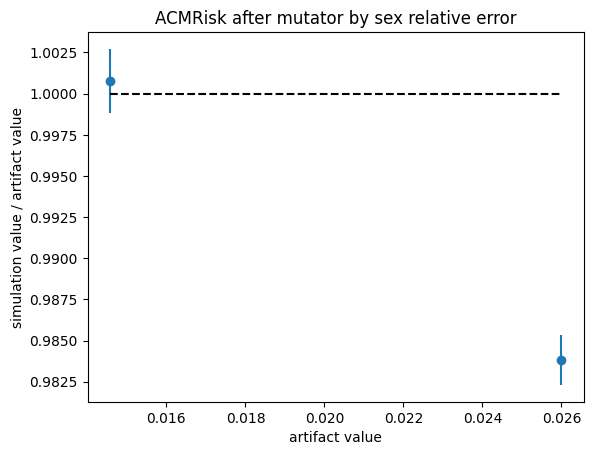

In [39]:
step_by_step_check_acmrisk(0, LATE_NEONATAL_AGE_START)

### Check cause-specific mortality risks

In [40]:
def get_csmrisk_targets(artifact_cause_name, age_group_start, age_group_end):
    return (
        art.load(f'cause.{artifact_cause_name}.mortality_risk')[f'draw_{draw_num}'].reset_index()
        .pipe(lambda df: df[(df.child_age_start == age_group_start) & (df.child_age_end == age_group_end)])
        .drop(columns=['child_age_start', 'child_age_end', 'year_start', 'year_end'])
        .set_index('sex_of_child')
        [f'draw_{draw_num}']
    )

neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma
Targets


sex_of_child
Female    0.004124
Male      0.009226
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.004360,0.013873,0.000726,0.000726,0.000876,0.001753,0.222757
Male,2820853.0,0.009783,0.025422,0.001403,0.001411,0.001899,0.004655,0.298372


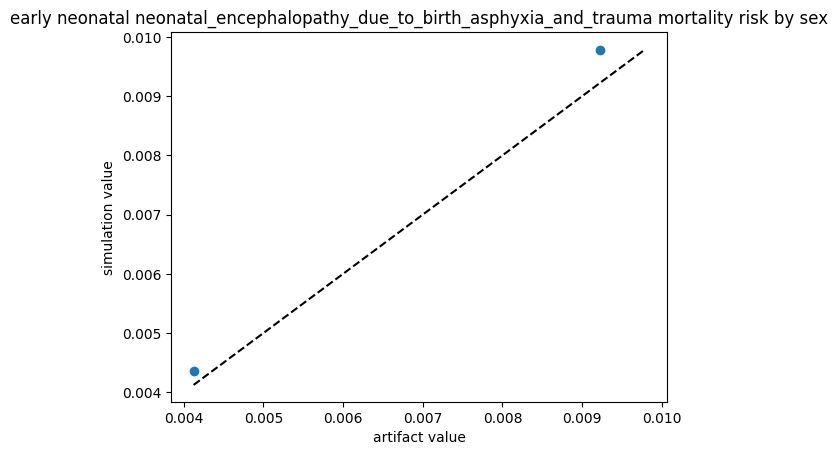

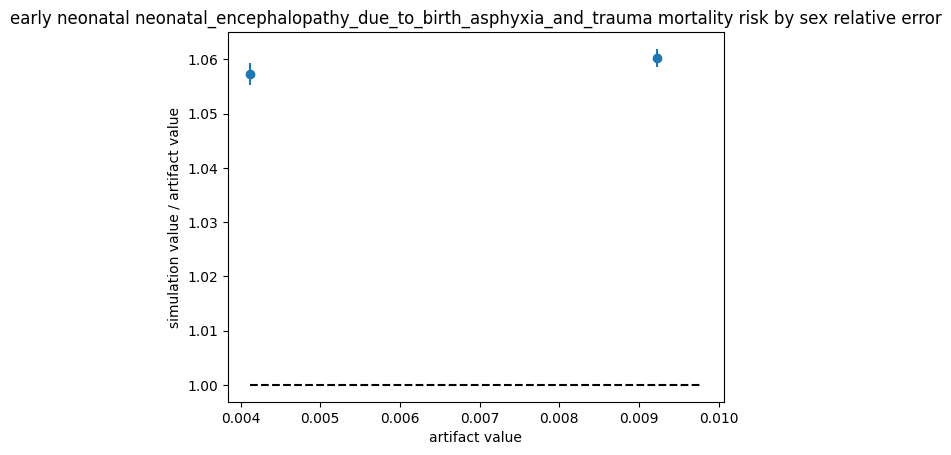

neonatal_sepsis_and_other_neonatal_infections
Targets


sex_of_child
Female    0.000861
Male      0.002649
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.000819,0.002569,0.000144,0.000144,0.000173,0.000341,0.044087
Male,2820853.0,0.002517,0.006505,0.000382,0.000384,0.000514,0.001232,0.081167


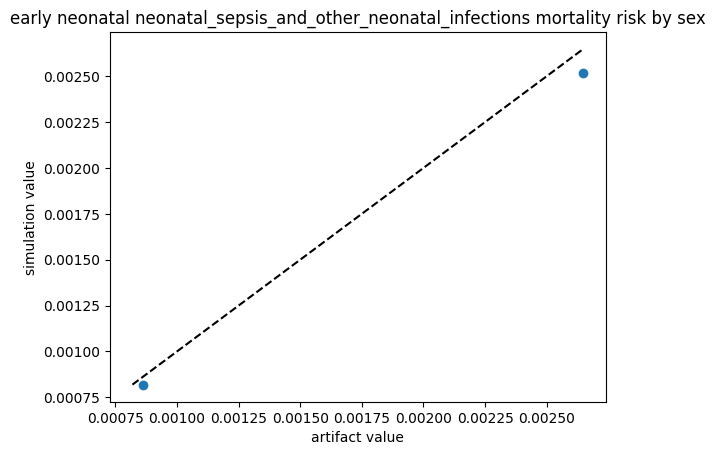

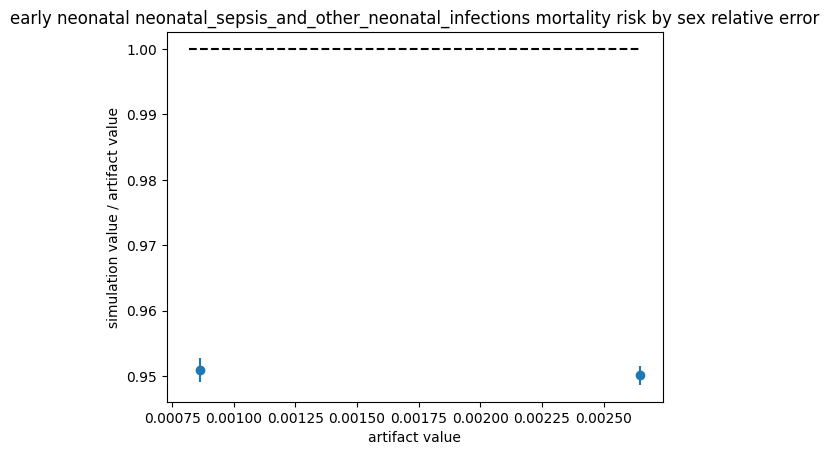

neonatal_preterm_birth
Targets


sex_of_child
Female    0.003228
Male      0.007147
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.002641,0.015295,0.0,0.0,0.0,0.0,0.336573
Male,2820853.0,0.005806,0.025229,0.0,0.0,0.0,0.0,0.429026


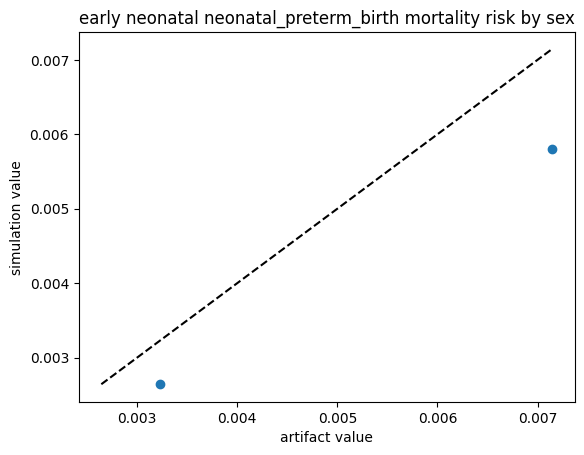

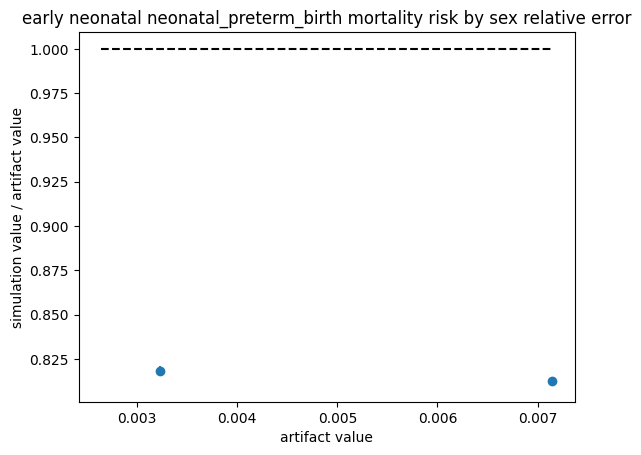

neonatal_preterm_birth_with_rds
Targets


sex_of_child
Female    0.002744
Male      0.006075
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.002135,0.012874,0.0,0.0,0.0,0.0,0.291142
Male,2820853.0,0.004681,0.021225,0.0,0.0,0.0,0.0,0.371117


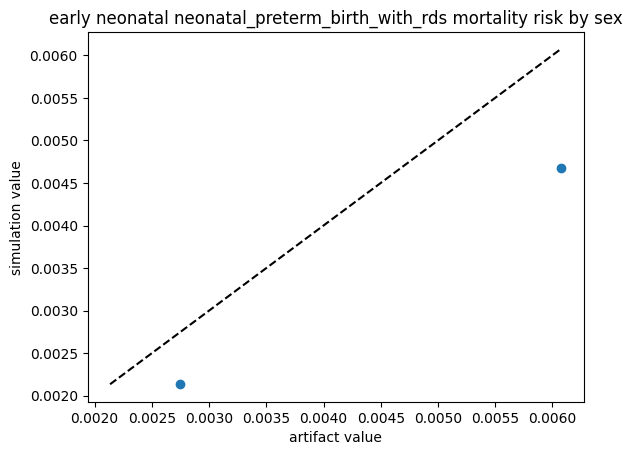

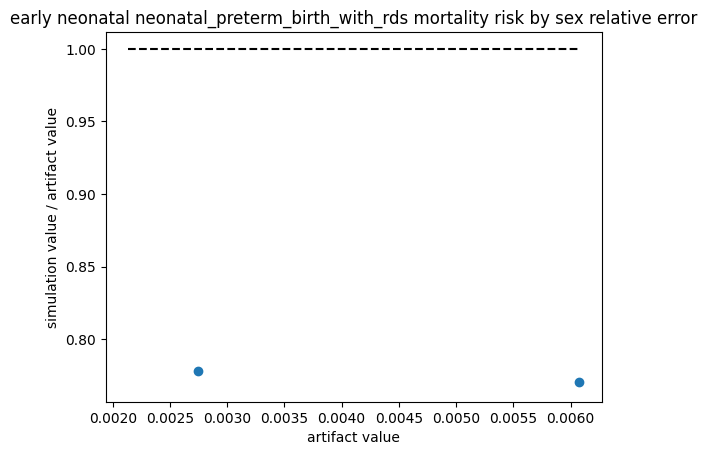

neonatal_preterm_birth_without_rds
Targets


sex_of_child
Female    0.000484
Male      0.001072
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.000506,0.002633,0.0,0.0,0.0,0.0,0.04543
Male,2820853.0,0.001125,0.004390,0.0,0.0,0.0,0.0,0.05791


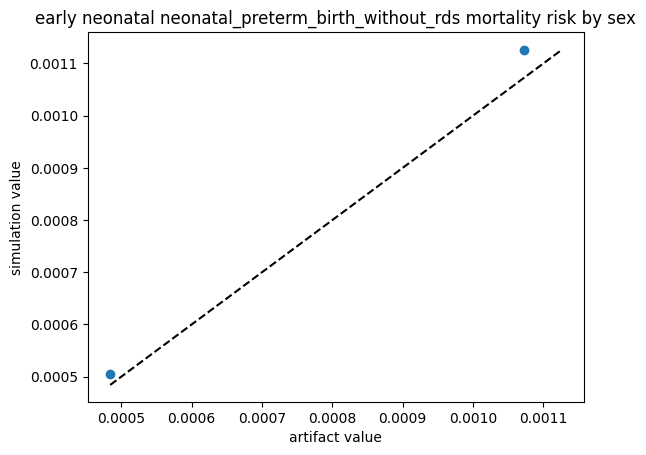

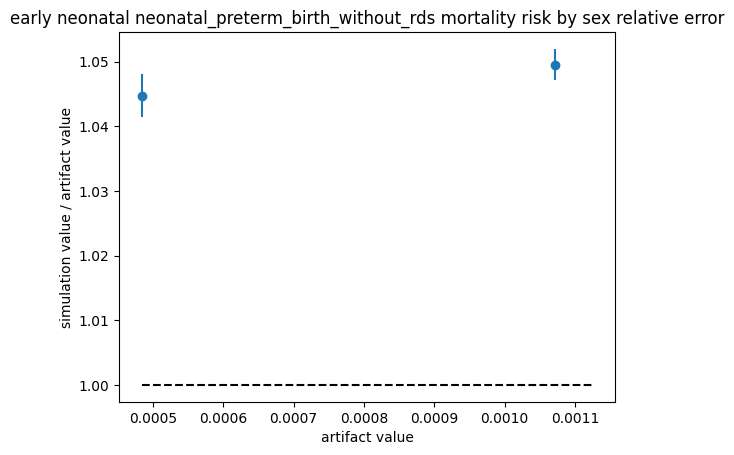

In [42]:
from vivarium_gates_mncnh.constants.data_values import PRETERM_DEATHS_DUE_TO_RDS_PROBABILITY

NEONATAL_CAUSES = [
    'neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma',
    'neonatal_sepsis_and_other_neonatal_infections',
    'neonatal_preterm_birth',
    'neonatal_preterm_birth_with_rds',
    'neonatal_preterm_birth_without_rds',
]

CAUSE_NAME_TO_CSMRISK_PIPELINES = {}
for cause_name in NEONATAL_CAUSES:
    if cause_name == 'neonatal_preterm_birth':
        CAUSE_NAME_TO_CSMRISK_PIPELINES[cause_name] = [
            "neonatal_preterm_birth_with_rds.csmr",
            "neonatal_preterm_birth_without_rds.csmr",
        ]
    else:
        CAUSE_NAME_TO_CSMRISK_PIPELINES[cause_name] = [f"{cause_name}.csmr"]

def check_csmrisks(age_group_start, age_group_end):
    for cause_name in NEONATAL_CAUSES:
        print(cause_name)

        pipeline_names = CAUSE_NAME_TO_CSMRISK_PIPELINES[cause_name]
        csmrisk_values = 0
        for pipeline_name in pipeline_names:
            csmrisk_values += (
                main_sim.get_population(pipeline_name).loc[alive_idx]
            )

        artifact_cause_name = cause_name.replace('_with_rds', '').replace('_without_rds', '')
        csmrisk_targets = get_csmrisk_targets(artifact_cause_name, age_group_start, age_group_end)

        if cause_name == 'neonatal_preterm_birth_with_rds':
            csmrisk_targets *= PRETERM_DEATHS_DUE_TO_RDS_PROBABILITY
        elif cause_name == 'neonatal_preterm_birth_without_rds':
            csmrisk_targets *= (1 - PRETERM_DEATHS_DUE_TO_RDS_PROBABILITY)

        # Add acceptable deviation in LNN for CPAP PAF not being age-specific
        acceptable_deviation = (
            0.02
            if age_group_start == LATE_NEONATAL_AGE_START and cause_name in ('neonatal_preterm_birth', 'neonatal_preterm_birth_with_rds')
            else None
        )
        fuzzy_check(csmrisk_values, csmrisk_targets, f"early neonatal {cause_name} mortality risk", acceptable_deviation=acceptable_deviation)

check_csmrisks(0, LATE_NEONATAL_AGE_START)

#### Check frequency of negative other-causes mortality, and impact

This isn't the best check because it is only for a single draw and location. In the one I've chosen, this rarely happens, apparently.

In [43]:
csmrisk_pipeline_names = sorted({item for values in CAUSE_NAME_TO_CSMRISK_PIPELINES.values() for item in values})
csmrisk_pipeline_names

['neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma.csmr',
 'neonatal_preterm_birth_with_rds.csmr',
 'neonatal_preterm_birth_without_rds.csmr',
 'neonatal_sepsis_and_other_neonatal_infections.csmr']

In [44]:
total_csmrisk = 0

for pipeline_name in csmrisk_pipeline_names:
    total_csmrisk += (
        main_sim.get_population(pipeline_name).loc[alive_idx]
    )

total_csmrisk

1          0.001785
3          0.002109
4          0.002098
5          0.067353
6          0.051570
             ...   
9999990    0.001137
9999995    0.001851
9999996    0.000882
9999997    0.100122
9999998    0.001042
Name: neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma.csmr, Length: 5475223, dtype: float64

In [45]:
total_csmrisk.describe()

count    5.475223e+06
mean     1.311887e-02
std      4.455615e-02
min      8.698213e-04
25%      1.069624e-03
50%      1.849667e-03
75%      4.625443e-03
max      8.085652e-01
Name: neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma.csmr, dtype: float64

In [46]:
(total_csmrisk > mortality_risk).mean()

0.0

In [47]:
# Expect CSMRisks to be underestimated by this amount as a result
(total_csmrisk - mortality_risk).clip(0).sum() / total_csmrisk.sum()

0.0

#### Check individual steps in calculation of cause-specific mortality risks

In [51]:
def step_by_step_check_csmrisk(cause_name, age_group_start, age_group_end):
    artifact_cause_name = cause_name.replace('_with_rds', '').replace('_without_rds', '')
    csmrisk_targets = get_csmrisk_targets(artifact_cause_name, age_group_start, age_group_end)

    # https://github.com/ihmeuw/vivarium_gates_mncnh/blob/86f8e36e8f781549cd6671cba9ad33912638dc4a/src/vivarium_gates_mncnh/components/mortality.py#L357-L361
    print('Initial cause-specific mortality risk')
    component_name = ('preterm_birth.' if 'preterm_birth' in cause_name else 'neonatal_cause.') + cause_name
    component = main_sim_components[component_name]
    initial_csmrisk = component.csmrisk_table(alive_idx)
    # Does not vary except by sex
    assert (initial_csmrisk.groupby(pop.sex_of_child).nunique() == 1).all()
    # Exactly matches artifact values
    assert np.allclose(initial_csmrisk.groupby(pop.sex_of_child).mean(), csmrisk_targets, rtol=0, atol=1e-14)
    display(initial_csmrisk.groupby(pop.sex_of_child).mean())

    # https://github.com/ihmeuw/vivarium_gates_mncnh/blob/7886d2bcb71fd2c3e497997a2bcf44c43569b8ab/src/vivarium_gates_mncnh/components/neonatal_causes.py#L116-L136
    global any_failures
    if 'preterm_birth' in cause_name:
        # Next step (conceptually) is limiting to preterm babies
        print('Preterm prevalence:')
        prevalence = component.prevalence_table(alive_idx)
        # Does not vary except by sex
        assert (prevalence.groupby(pop.sex_of_child).nunique() == 1).all()
        display(prevalence.groupby(pop.sex_of_child).mean())

        ga_greater_than_37 = main_sim.get_population("gestational_age.exposure").loc[alive_idx] >= 37.0
        for sex in ['Female', 'Male']:
            try:
                fuzzy_checker.fuzzy_assert_proportion(
                    (~ga_greater_than_37)[pop.loc[alive_idx].sex_of_child == sex].sum(),
                    (pop.loc[alive_idx].sex_of_child == sex).sum(),
                    prevalence[pop.sex_of_child == sex].mean()
                )
            except AssertionError as e:
                print(e)
                any_failures = True
    
        limited_csmrisk_preterm = initial_csmrisk / prevalence
        limited_csmrisk_preterm.loc[ga_greater_than_37] = 0
        display(limited_csmrisk_preterm.groupby(pop.sex_of_child).mean())

        fuzzy_check(limited_csmrisk_preterm, csmrisk_targets, "CSMRisk after limiting to preterm")

        working_csmrisk = limited_csmrisk_preterm

        if cause_name == 'neonatal_preterm_birth_with_rds':
            working_csmrisk = working_csmrisk * PRETERM_DEATHS_DUE_TO_RDS_PROBABILITY
            csmrisk_targets = csmrisk_targets * PRETERM_DEATHS_DUE_TO_RDS_PROBABILITY
        elif cause_name == 'neonatal_preterm_birth_without_rds':
            working_csmrisk = working_csmrisk * (1 - PRETERM_DEATHS_DUE_TO_RDS_PROBABILITY)
            csmrisk_targets = csmrisk_targets * (1 - PRETERM_DEATHS_DUE_TO_RDS_PROBABILITY)
        
        fuzzy_check(working_csmrisk, csmrisk_targets, "CSMRisk after splitting to subcause")
    else:
        working_csmrisk = initial_csmrisk

    if age_group_start == 0 and age_group_end == LATE_NEONATAL_AGE_START:
        age_group_name = 'early_neonatal'
    elif age_group_start == LATE_NEONATAL_AGE_START and age_group_end == LATE_NEONATAL_AGE_END:
        age_group_name = 'late_neonatal'
    else:
        raise ValueError("Unknown age group")

    # Next (conceptually) is applying LBWSG PAF/normalizing constant and RR
    # TODO: Why is this different! Note that there is a PAF table on the risk effect, but it is not actually used!
    if 'preterm_birth' in cause_name:
        lbwsg_paf = component.paf_table(alive_idx)
    else:
        lbwsg_paf = main_sim_components[f'risk_effect.low_birth_weight_and_short_gestation_on_cause.{cause_name}.cause_specific_mortality_risk'].paf_table(alive_idx)
    lbwsg_rr = main_sim.get_population(f'effect_of_low_birth_weight_and_short_gestation_on_{age_group_name}_{cause_name}_relative_risk').loc[alive_idx]

    csmrisk_after_lbwsg = working_csmrisk * (1 - lbwsg_paf) * lbwsg_rr
    print('After LBWSG:')
    display(csmrisk_after_lbwsg.groupby(pop.sex_of_child).describe())

    fuzzy_check(csmrisk_after_lbwsg, csmrisk_targets, "CSMRisk after LBWSG")

    pipeline_names = CAUSE_NAME_TO_CSMRISK_PIPELINES[cause_name]
    assert len(pipeline_names) == 1
    pop_mgr = main_sim._builder.population._manager
    pipeline = pop_mgr._get_attribute_pipelines()[pipeline_names[0]]

    # Check that we've exactly replicated everything up to mutators
    assert np.allclose(csmrisk_after_lbwsg, pipeline.source(pop_mgr, alive_idx), rtol=0, atol=1e-14)

    # Now we add in intervention-based modifications
    print('Mutators:')
    display(pipeline.mutators)

    working_csmrisk = csmrisk_after_lbwsg

    for mutator in pipeline.mutators:
        print(f'After {mutator}')
        working_csmrisk = mutator(alive_idx, working_csmrisk)
        # Add acceptable deviation in LNN for CPAP PAF not being age-specific
        acceptable_deviation = (
            0.02
            if age_group_name == 'late_neonatal' and cause_name in ('neonatal_preterm_birth', 'neonatal_preterm_birth_with_rds')
            else None
        )
        fuzzy_check(working_csmrisk, csmrisk_targets, "CSMRisk after mutator", acceptable_deviation=acceptable_deviation)

    # Check that we've exactly replicated everything
    assert np.allclose(working_csmrisk, pipeline(alive_idx), rtol=0, atol=1e-14)

neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma
Initial cause-specific mortality risk


sex_of_child
Female    0.004124
Male      0.009226
Name: value, dtype: float64

After LBWSG:


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.004360,0.013873,0.000726,0.000726,0.000876,0.001753,0.222757
Male,2820853.0,0.009783,0.025422,0.001403,0.001411,0.001899,0.004655,0.298372


Targets


sex_of_child
Female    0.004124
Male      0.009226
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.004360,0.013873,0.000726,0.000726,0.000876,0.001753,0.222757
Male,2820853.0,0.009783,0.025422,0.001403,0.001411,0.001899,0.004655,0.298372


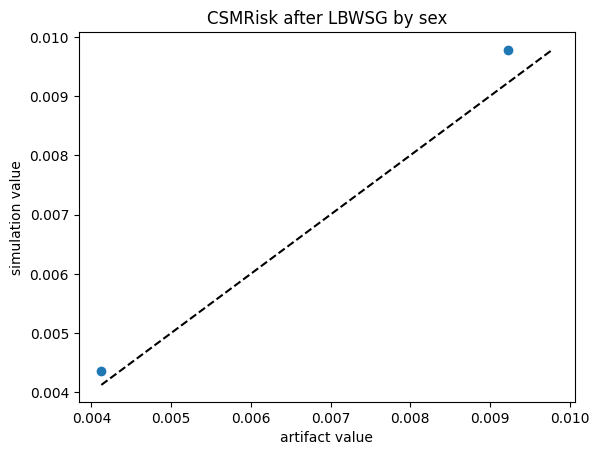

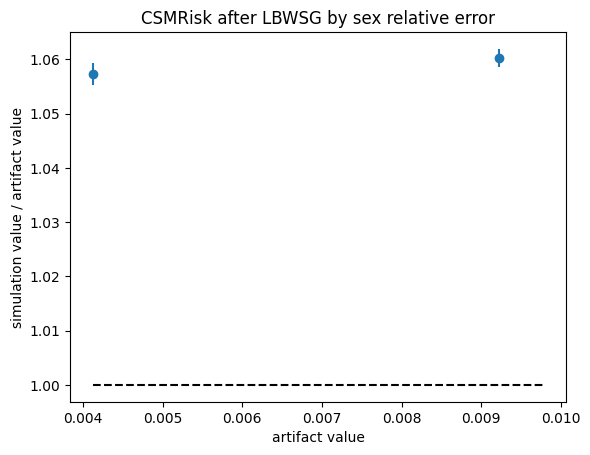

Mutators:


[]

neonatal_sepsis_and_other_neonatal_infections
Initial cause-specific mortality risk


sex_of_child
Female    0.000861
Male      0.002649
Name: value, dtype: float64

After LBWSG:


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.000911,0.002897,0.000152,0.000152,0.000183,0.000366,0.046525
Male,2820853.0,0.002808,0.007298,0.000403,0.000405,0.000545,0.001336,0.085655


Targets


sex_of_child
Female    0.000861
Male      0.002649
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.000911,0.002897,0.000152,0.000152,0.000183,0.000366,0.046525
Male,2820853.0,0.002808,0.007298,0.000403,0.000405,0.000545,0.001336,0.085655


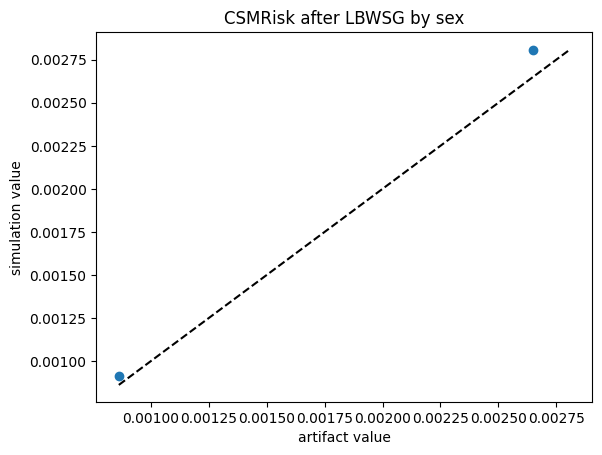

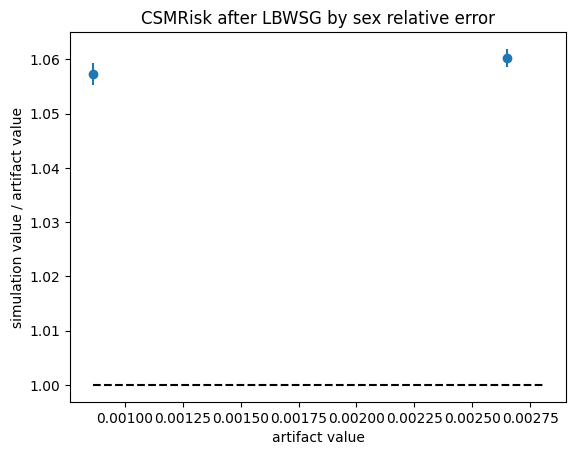

Mutators:


After <vivarium.framework.values.pipeline.ValueModifier object at 0x7f2f694be6d0>
Targets


sex_of_child
Female    0.000861
Male      0.002649
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.000863,0.002746,0.000144,0.000144,0.000173,0.000347,0.044087
Male,2820853.0,0.002661,0.006916,0.000382,0.000384,0.000517,0.001266,0.081167


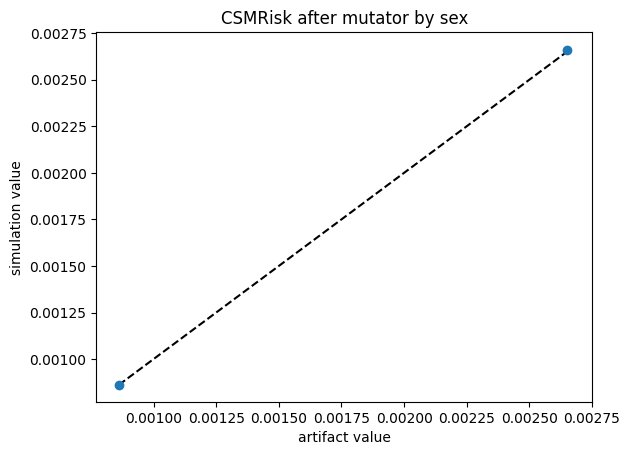

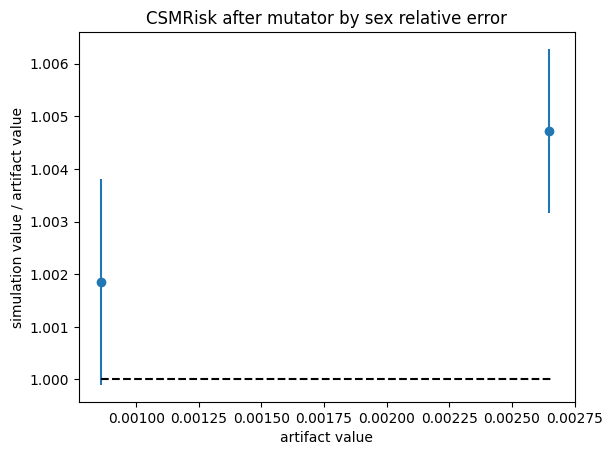

After <vivarium.framework.values.pipeline.ValueModifier object at 0x7f2f6963fb10>
Targets


sex_of_child
Female    0.000861
Male      0.002649
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.000819,0.002569,0.000144,0.000144,0.000173,0.000341,0.044087
Male,2820853.0,0.002517,0.006505,0.000382,0.000384,0.000514,0.001232,0.081167


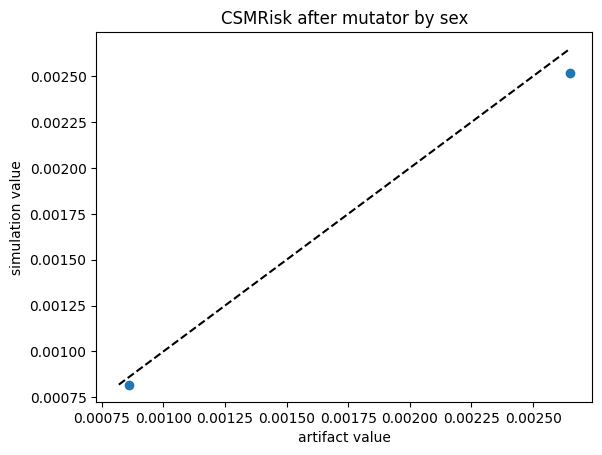

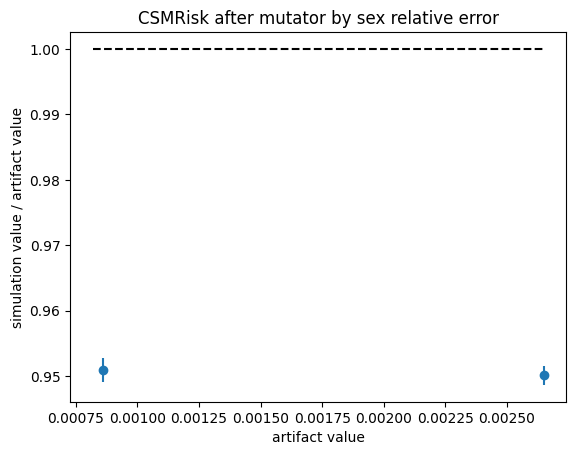

neonatal_preterm_birth_with_rds
Initial cause-specific mortality risk


sex_of_child
Female    0.003228
Male      0.007147
Name: value, dtype: float64

Preterm prevalence:


sex_of_child
Female    0.139787
Male      0.190916
Name: value, dtype: float64

 value 0.147373 is significantly greater than expected, bayes factor = 2.82522e+268
 value 0.198782 is significantly greater than expected, bayes factor = 3.60281e+239


sex_of_child
Female    0.003404
Male      0.007441
Name: value, dtype: float64

Targets


sex_of_child
Female    0.003228
Male      0.007147
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.003404,0.008187,0.0,0.0,0.0,0.0,0.023095
Male,2820853.0,0.007441,0.014940,0.0,0.0,0.0,0.0,0.037435


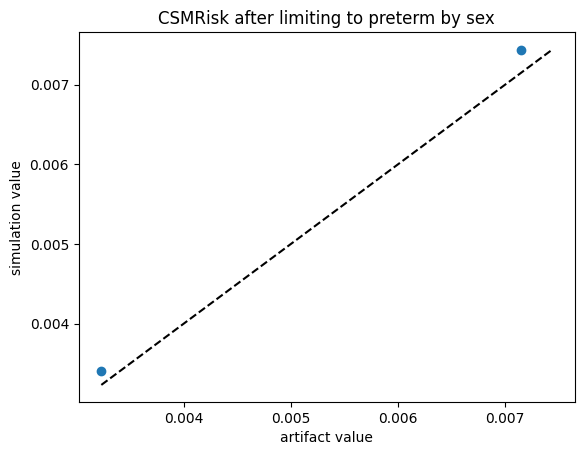

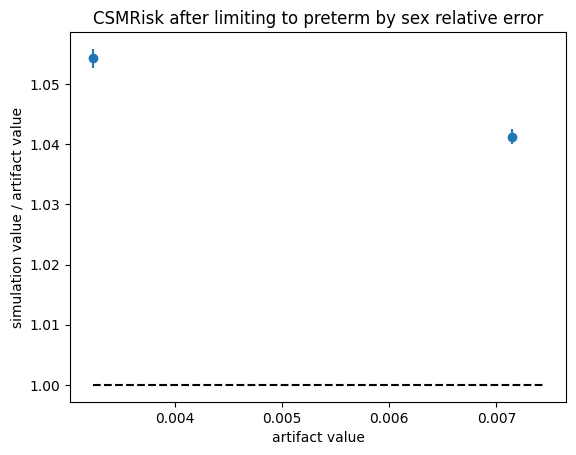

Targets


sex_of_child
Female    0.002744
Male      0.006075
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.002893,0.006959,0.0,0.0,0.0,0.0,0.019631
Male,2820853.0,0.006325,0.012699,0.0,0.0,0.0,0.0,0.031820


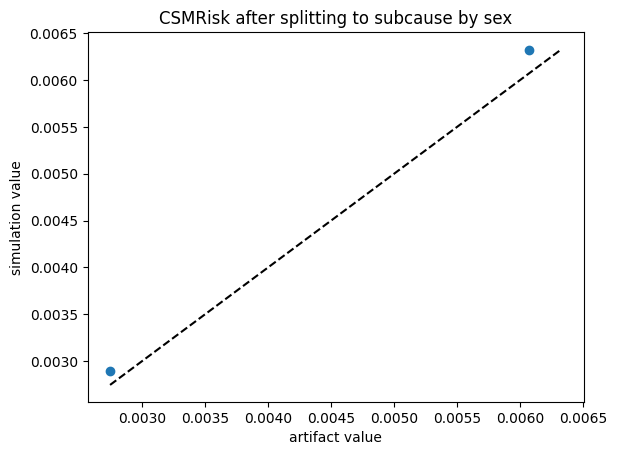

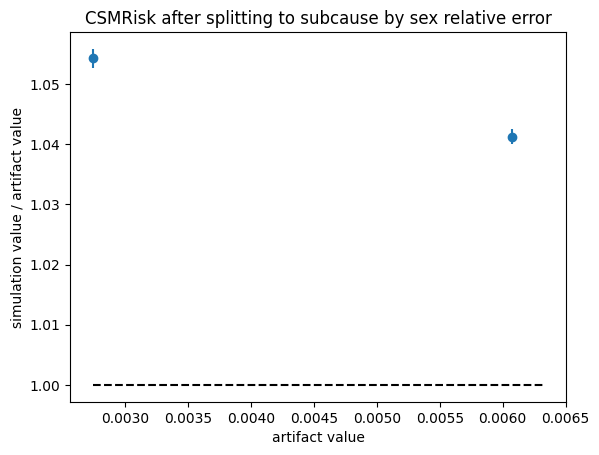

After LBWSG:


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.002867,0.014922,0.0,0.0,0.0,0.0,0.257439
Male,2820853.0,0.006376,0.024875,0.0,0.0,0.0,0.0,0.328155


Targets


sex_of_child
Female    0.002744
Male      0.006075
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.002867,0.014922,0.0,0.0,0.0,0.0,0.257439
Male,2820853.0,0.006376,0.024875,0.0,0.0,0.0,0.0,0.328155


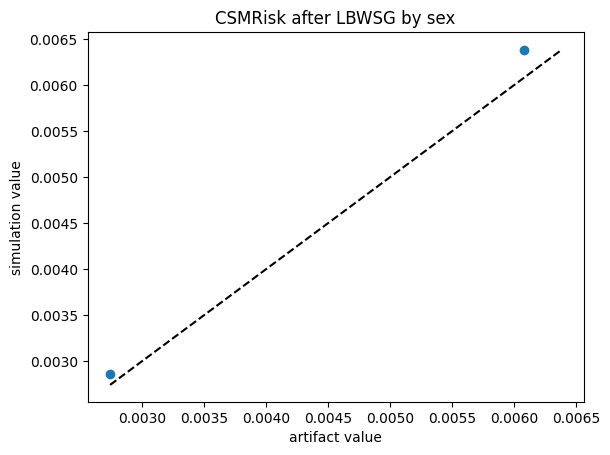

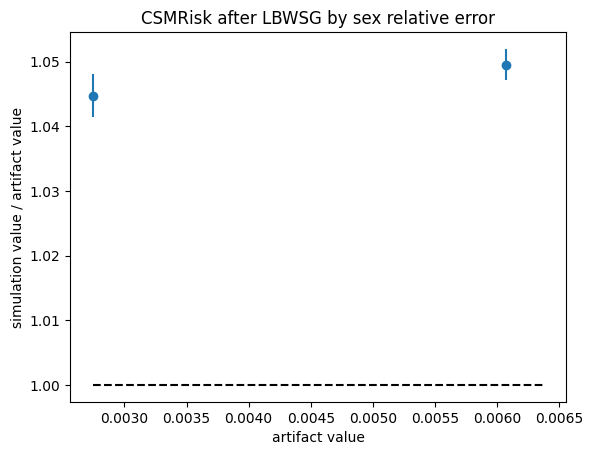

Mutators:


After <vivarium.framework.values.pipeline.ValueModifier object at 0x7f2f69325a10>
Targets


sex_of_child
Female    0.002744
Male      0.006075
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.002135,0.012874,0.0,0.0,0.0,0.0,0.291142
Male,2820853.0,0.004681,0.021225,0.0,0.0,0.0,0.0,0.371117


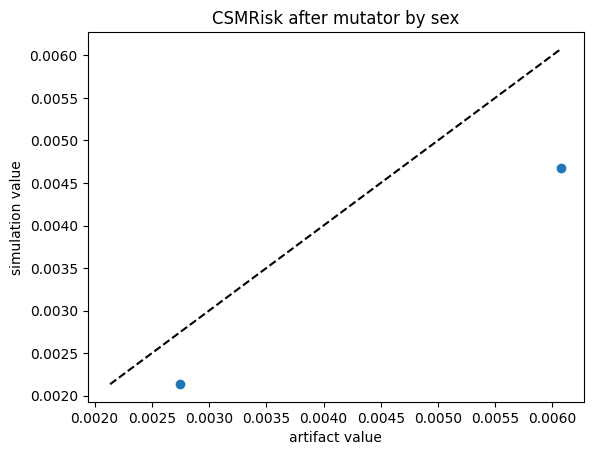

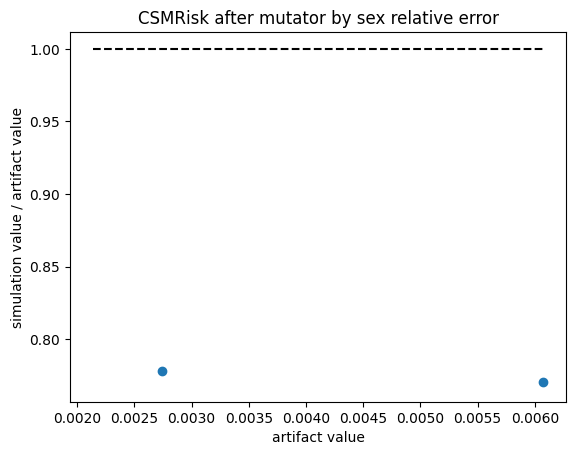

neonatal_preterm_birth_without_rds
Initial cause-specific mortality risk


sex_of_child
Female    0.003228
Male      0.007147
Name: value, dtype: float64

Preterm prevalence:


sex_of_child
Female    0.139787
Male      0.190916
Name: value, dtype: float64

 value 0.147373 is significantly greater than expected, bayes factor = 2.82522e+268
 value 0.198782 is significantly greater than expected, bayes factor = 3.60281e+239


sex_of_child
Female    0.003404
Male      0.007441
Name: value, dtype: float64

Targets


sex_of_child
Female    0.003228
Male      0.007147
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.003404,0.008187,0.0,0.0,0.0,0.0,0.023095
Male,2820853.0,0.007441,0.014940,0.0,0.0,0.0,0.0,0.037435


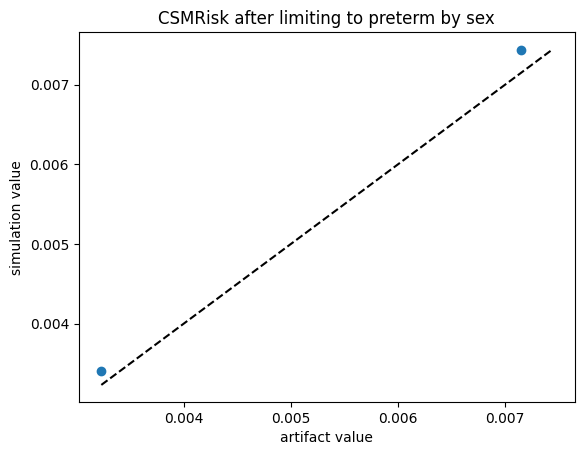

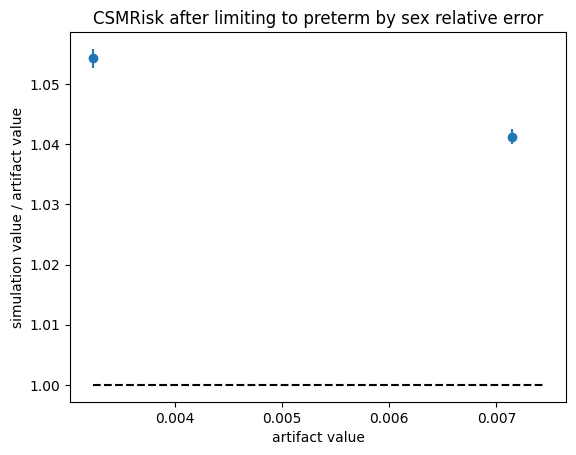

Targets


sex_of_child
Female    0.000484
Male      0.001072
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.000511,0.001228,0.0,0.0,0.0,0.0,0.003464
Male,2820853.0,0.001116,0.002241,0.0,0.0,0.0,0.0,0.005615


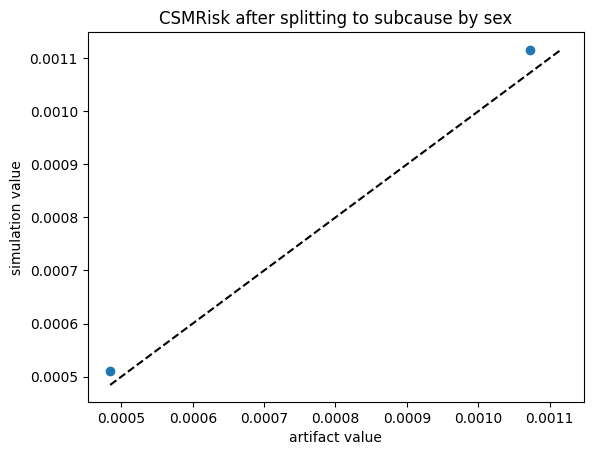

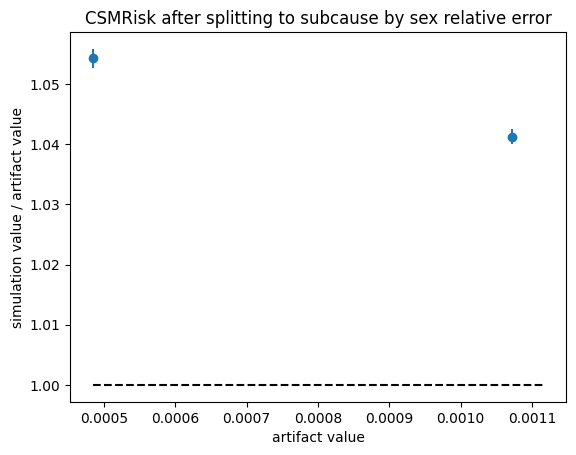

After LBWSG:


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.000506,0.002633,0.0,0.0,0.0,0.0,0.04543
Male,2820853.0,0.001125,0.004390,0.0,0.0,0.0,0.0,0.05791


Targets


sex_of_child
Female    0.000484
Male      0.001072
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2654370.0,0.000506,0.002633,0.0,0.0,0.0,0.0,0.04543
Male,2820853.0,0.001125,0.004390,0.0,0.0,0.0,0.0,0.05791


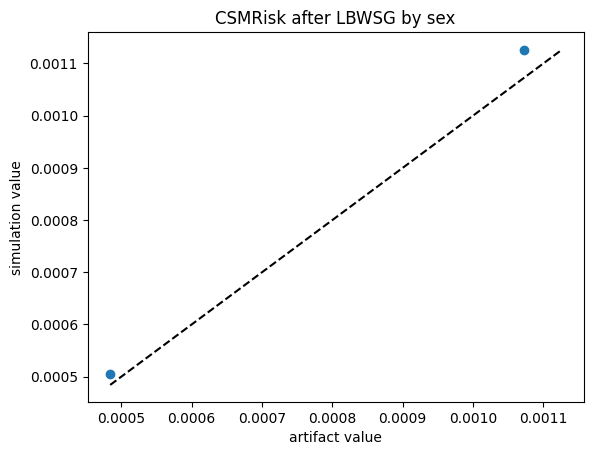

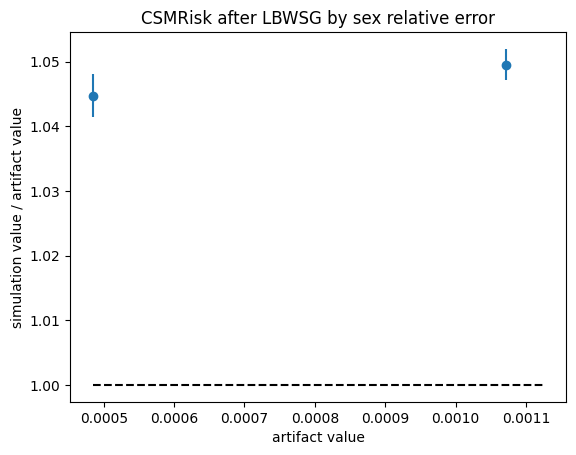

Mutators:


[]

In [52]:
for cause_name in NEONATAL_CAUSES:
    if cause_name == 'neonatal_preterm_birth':
        continue
    print(cause_name)
    step_by_step_check_csmrisk(cause_name, 0, LATE_NEONATAL_AGE_START)

## LNN mortality

### Step main sim to LNN mortality

In [53]:
get_event_name = main_sim._builder.time.simulation_event_name()
get_event_name()

'early_neonatal_mortality'

In [54]:
%%time

while get_event_name() != 'late_neonatal_mortality':
    main_sim.step()
    print(get_event_name())

2026-05-14 17:37:47.300 | INFO     | simulation_1 - vivarium.framework.engine:280 - 2025-01-19 00:00:00
late_neonatal_mortality
CPU times: user 12min 36s, sys: 4min 59s, total: 17min 35s
Wall time: 17min 2s


In [55]:
assert get_event_name() == 'late_neonatal_mortality'

In [56]:
# We now step to the *middle* of a time step
# https://github.com/ihmeuw/vivarium/blob/aeaa9e03ecbf67929a1ce94e934c2c14ececfa29/src/vivarium/framework/engine.py#L260-L268
self = main_sim
for event in self.time_step_events:
    self._lifecycle.set_state(event)
    pop_to_update = self._clock.get_active_simulants(
        self.get_population_index(),
        self._clock.event_time,
    )
    # https://github.com/ihmeuw/vivarium/blob/aeaa9e03ecbf67929a1ce94e934c2c14ececfa29/src/vivarium/framework/event.py#L119-L141
    clock = self._events.clock()
    step_size = self._events.step_size()
    event_time = clock + step_size

    e = Event(
        "time_step",
        pop_to_update,
        {},
        event_time,
        step_size,
    )

    listener = None
    listeners = self.time_step_emitters[event].__self__.listeners
    for priority_bucket in listeners:
        for listener in priority_bucket:
            if listener.__self__.__class__.__name__ == "NeonatalMortality" and event == "time_step":
                break
            listener(e)
        if listener is not None and listener.__self__.__class__.__name__ == "NeonatalMortality" and event == "time_step":
            break

    if listener is not None and listener.__self__.__class__.__name__ == "NeonatalMortality" and event == "time_step":
            break

In [57]:
assert listener.__self__.__class__.__name__ == "NeonatalMortality" and event == "time_step"

In [58]:
pop = main_sim.get_population([
    "child_alive",
    "child_age",
])
assert (pop[pop.child_alive == True].child_age >= LATE_NEONATAL_AGE_START).all()
assert (pop[pop.child_alive == True].child_age < LATE_NEONATAL_AGE_END).all()

In [59]:
alive_idx = pop.index[pop['child_alive'] == True]

### Feed ENN PAFs back into the PAF sim

In [60]:
acmr_paf_components = [k for k in paf_sim_components if 'risk_effect.low_birth_weight_' in k]
acmr_paf_components

['risk_effect.low_birth_weight_and_short_gestation_on_cause.all_causes.all_cause_mortality_risk']

In [61]:
for component in acmr_paf_components:
    update_lookup_table(paf_sim_components[component].paf_table, acmrisk_pafs)

In [62]:
# Check that our transfer actually worked
assert (
    set(paf_sim.get_population("all_causes.all_cause_mortality_risk.paf").loc[alive_idx])
    <=
    set(acmrisk_pafs['value'].unique())
)

### Step PAF sim to LNN

In [63]:
%%time

assert (paf_sim.get_population("child_age") < LATE_NEONATAL_AGE_START).all()
paf_sim.step()

2026-05-14 17:56:55.341 | INFO     | simulation_2 - vivarium.framework.engine:280 - 2022-01-01 00:00:00
CPU times: user 52.8 s, sys: 21.9 s, total: 1min 14s
Wall time: 1min 12s


In [64]:
paf_sim_pop = paf_sim.get_population([
    "child_alive",
    "child_age",
])
assert (paf_sim_pop[paf_sim_pop.child_alive == True].child_age >= LATE_NEONATAL_AGE_START).all()
assert (paf_sim_pop[paf_sim_pop.child_alive == True].child_age < LATE_NEONATAL_AGE_END).all()

### Transfer PAFs and preterm prevalence to main sim

In [65]:
paf_observer = paf_sim_components['lbwsgpaf_observer.cause.all_causes.all_cause_mortality_risk']

In [66]:
paf_sim._results.gather_results(Event(
    "time_step",
    index=paf_sim.get_population_index(),
    user_data={},
    time=paf_sim._clock.time,
    step_size=paf_sim._clock.step_size,
))

In [67]:
acmrisk_pafs = process_pafs(
    paf_sim.get_results()['calculated_lbwsg_paf_on_cause.all_causes.all_cause_mortality_risk']
)
acmrisk_pafs

,sex_of_child,value,child_age_start,child_age_end,year_start,year_end
0,Female,0.823918,0.000000,0.019178,2021,2022
1,Male,0.847904,0.000000,0.019178,2021,2022
2,Female,0.764094,0.019178,0.076712,2021,2022
3,Male,0.776489,0.019178,0.076712,2021,2022


In [68]:
preterm_csmr_pafs = process_pafs(
    paf_sim.get_results()['calculated_lbwsg_paf_on_cause.all_causes.all_cause_mortality_risk_preterm']
)
preterm_csmr_pafs

,sex_of_child,value,child_age_start,child_age_end,year_start,year_end
0,Female,0.957253,0.000000,0.019178,2021,2022
1,Male,0.951496,0.000000,0.019178,2021,2022
2,Female,0.929634,0.019178,0.076712,2021,2022
3,Male,0.913253,0.019178,0.076712,2021,2022


In [69]:
acmr_paf_components = [k for k in main_sim_components if 'risk_effect.low_birth_weight_' in k and 'preterm' not in k]
acmr_paf_components

['risk_effect.low_birth_weight_and_short_gestation_on_cause.all_causes.all_cause_mortality_risk',
 'risk_effect.low_birth_weight_and_short_gestation_on_cause.neonatal_sepsis_and_other_neonatal_infections.cause_specific_mortality_risk',
 'risk_effect.low_birth_weight_and_short_gestation_on_cause.neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma.cause_specific_mortality_risk']

In [70]:
for component in acmr_paf_components:
    update_lookup_table(main_sim_components[component].paf_table, acmrisk_pafs)

In [71]:
preterm_paf_components = [k for k in main_sim_components if ('risk_effect.low_birth_weight_' in k and 'preterm' in k) or ('preterm_birth.' in k)]
preterm_paf_components

['risk_effect.low_birth_weight_and_short_gestation_on_cause.neonatal_preterm_birth_with_rds.cause_specific_mortality_risk',
 'risk_effect.low_birth_weight_and_short_gestation_on_cause.neonatal_preterm_birth_without_rds.cause_specific_mortality_risk',
 'preterm_birth.neonatal_preterm_birth_with_rds',
 'preterm_birth.neonatal_preterm_birth_without_rds']

In [72]:
for component in preterm_paf_components:
    update_lookup_table(main_sim_components[component].paf_table, preterm_csmr_pafs)

In [73]:
late_neonatal_preterm_prevalence = paf_sim.get_results()['calculated_late_neonatal_preterm_prevalence'].assign(
    child_age_start=LATE_NEONATAL_AGE_START,
    child_age_end=LATE_NEONATAL_AGE_END,
    year_start=2023,
    year_end=2024,
).rename(columns={"child_sex": "sex_of_child"})
late_neonatal_preterm_prevalence

,sex_of_child,value,child_age_start,child_age_end,year_start,year_end
0,Female,0.133338,0.019178,0.076712,2023,2024
1,Male,0.180006,0.019178,0.076712,2023,2024


In [74]:
preterm_prevalence_components = [k for k in main_sim_components if 'preterm_birth.' in k]

for component in preterm_prevalence_components:
    lookup_table = main_sim_components[component].prevalence_table
    enn_data = lookup_table.data[lookup_table.data.child_age_start == 0]
    update_lookup_table(lookup_table, pd.concat([enn_data, late_neonatal_preterm_prevalence], ignore_index=True))

In [75]:
assert (
    set(main_sim_components['preterm_birth.neonatal_preterm_birth_with_rds'].prevalence_table(alive_idx).unique())
    <=
    set(late_neonatal_preterm_prevalence['value'].unique())
)

### Check all-cause mortality risk

In [76]:
# Check that our transfer above actually worked
assert (
    set(main_sim.get_population("all_causes.all_cause_mortality_risk.paf").unique())
    <=
    set(acmrisk_pafs['value'].unique())
)

In [77]:
# https://github.com/ihmeuw/vivarium_gates_mncnh/blob/9502fba51790f522523b8cd2925e539a692babf6/src/vivarium_gates_mncnh/components/mortality.py#L281-L283
pop = main_sim.get_population([
    "child_alive",
    "sex_of_child",
    "pregnancy_outcome",
    "effect_of_low_birth_weight_and_short_gestation_on_early_neonatal_all_causes_relative_risk",
    "effect_of_low_birth_weight_and_short_gestation_on_late_neonatal_all_causes_relative_risk"
])
alive_idx = pop.index[pop['child_alive'] == True]
mortality_risk = main_sim.get_population("death_in_age_group_probability").loc[alive_idx]

In [78]:
acmrisk_targets = get_acmrisk_targets(LATE_NEONATAL_AGE_START, LATE_NEONATAL_AGE_END)
acmrisk_targets

sex
Female    0.004313
Male      0.007330
Name: draw_60, dtype: float64

Targets


sex
Female    0.004313
Male      0.007330
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2615934.0,0.004438,0.013807,0.001009,0.001226,0.001769,0.003302,0.474391
Male,2748608.0,0.007413,0.019709,0.001617,0.002222,0.003274,0.006051,0.739529


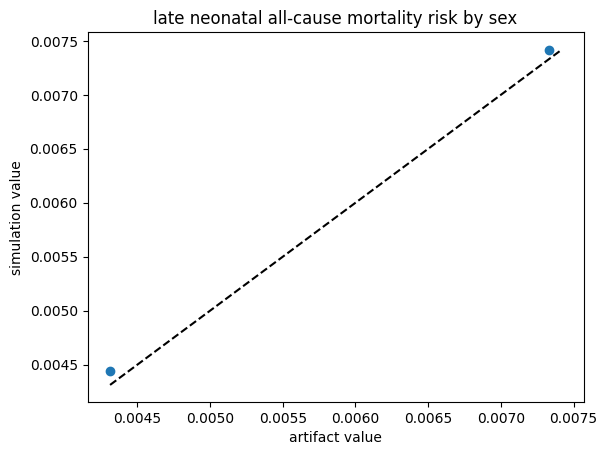

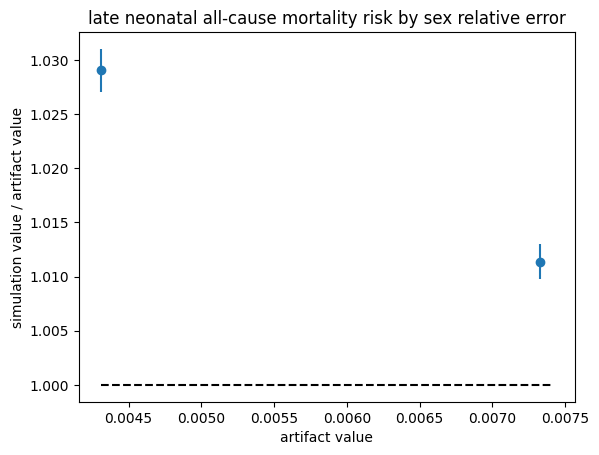

In [79]:
fuzzy_check(mortality_risk, acmrisk_targets, "late neonatal all-cause mortality risk", acceptable_deviation=0.01)

#### Check individual steps in calculation of all-cause mortality risk

Initial mortality risk


sex_of_child
Female    0.004313
Male      0.007330
Name: value, dtype: float64

After LBWSG:


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2615934.0,0.004636,0.014882,0.001017,0.001237,0.001791,0.003386,0.466695
Male,2748608.0,0.007933,0.022167,0.001638,0.002254,0.003360,0.006366,0.724046


Targets


sex
Female    0.004313
Male      0.007330
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2615934.0,0.004636,0.014882,0.001017,0.001237,0.001791,0.003386,0.466695
Male,2748608.0,0.007933,0.022167,0.001638,0.002254,0.003360,0.006366,0.724046


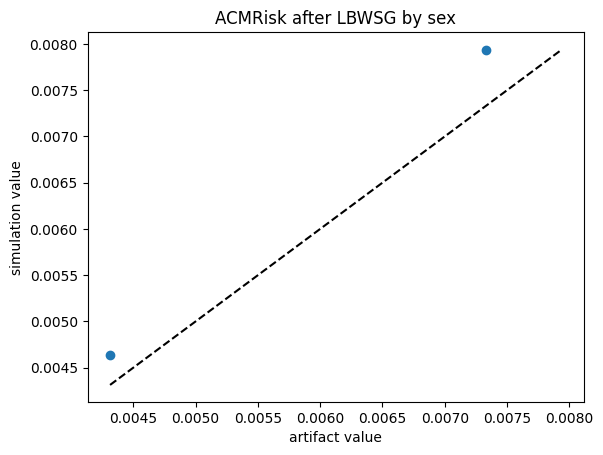

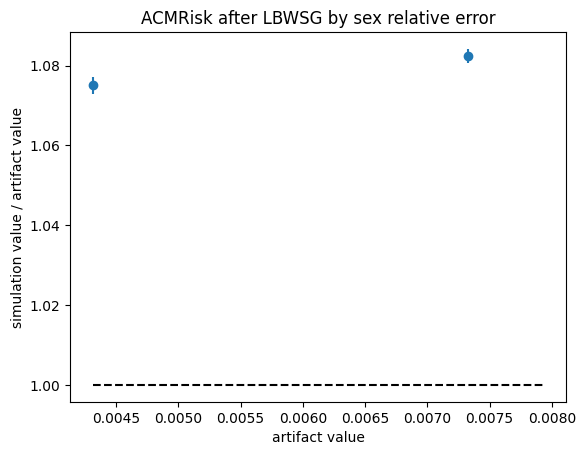

Mutators:


After <vivarium.framework.values.pipeline.ValueModifier object at 0x7f2f68c69950>
Targets


sex
Female    0.004313
Male      0.007330
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2615934.0,0.004510,0.014118,0.001017,0.001237,0.001786,0.003344,0.478451
Male,2748608.0,0.007602,0.020412,0.001638,0.002252,0.003327,0.006188,0.748782


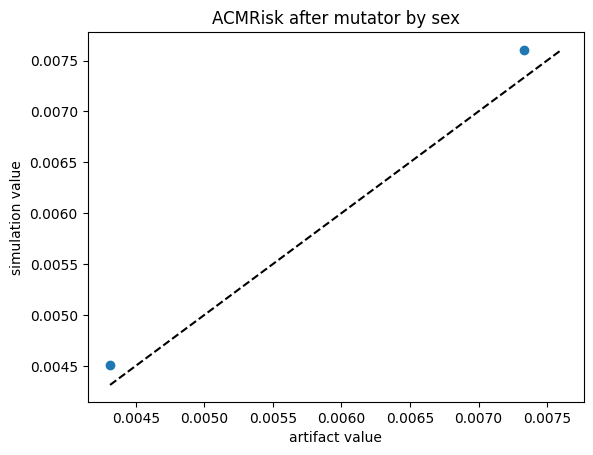

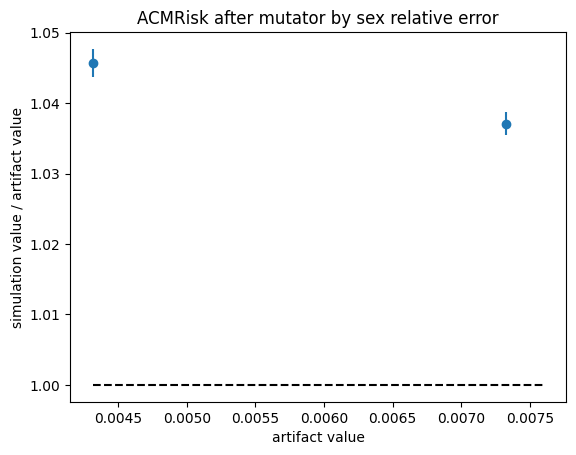

After <vivarium.framework.values.pipeline.ValueModifier object at 0x7f2f68c2d410>
Targets


sex
Female    0.004313
Male      0.007330
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2615934.0,0.004510,0.014118,0.001017,0.001237,0.001786,0.003344,0.478451
Male,2748608.0,0.007602,0.020412,0.001638,0.002252,0.003327,0.006188,0.748782


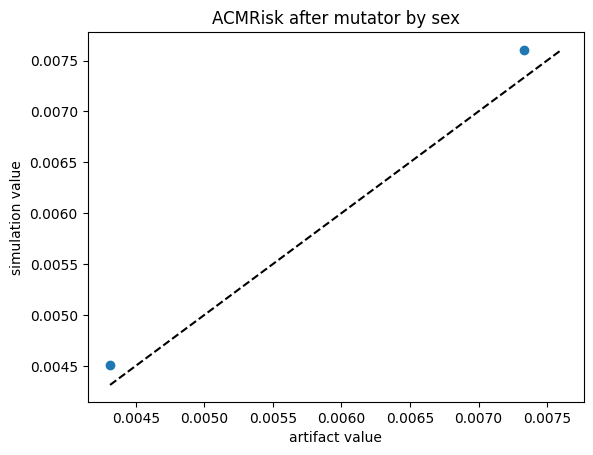

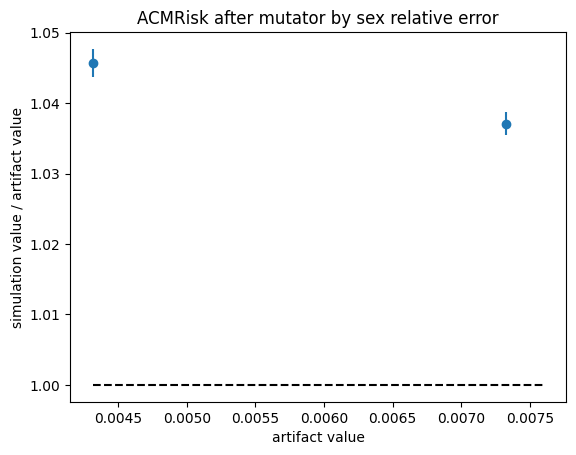

After <vivarium.framework.values.pipeline.ValueModifier object at 0x7f2f68c30e90>
Targets


sex
Female    0.004313
Male      0.007330
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2615934.0,0.004438,0.013807,0.001009,0.001226,0.001769,0.003302,0.474391
Male,2748608.0,0.007413,0.019709,0.001617,0.002222,0.003274,0.006051,0.739529


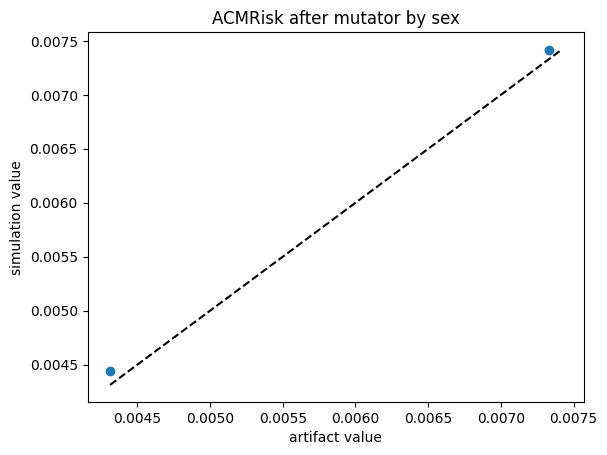

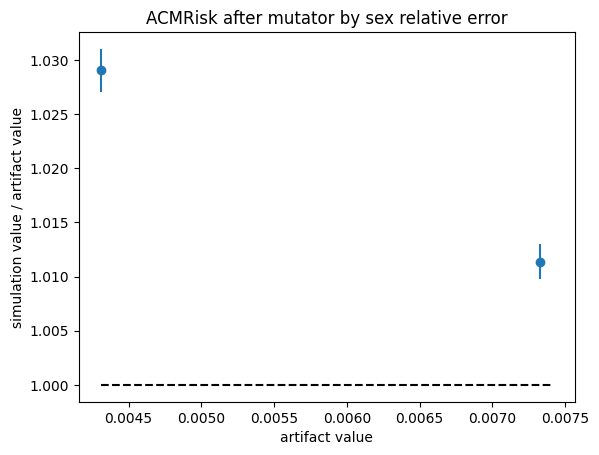

After <vivarium.framework.values.pipeline.ValueModifier object at 0x7f2f68c8cf10>
Targets


sex
Female    0.004313
Male      0.007330
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2615934.0,0.004438,0.013807,0.001009,0.001226,0.001769,0.003302,0.474391
Male,2748608.0,0.007413,0.019709,0.001617,0.002222,0.003274,0.006051,0.739529


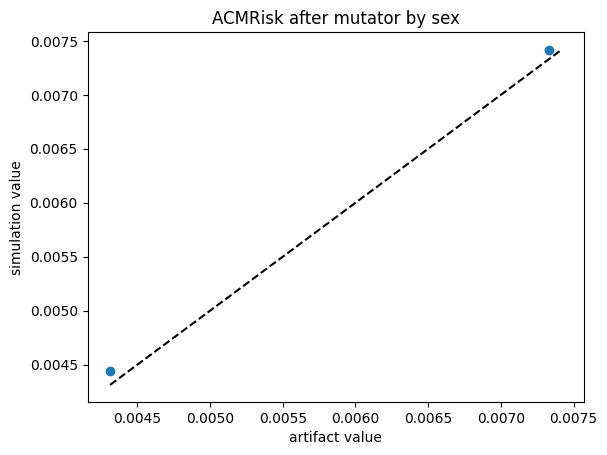

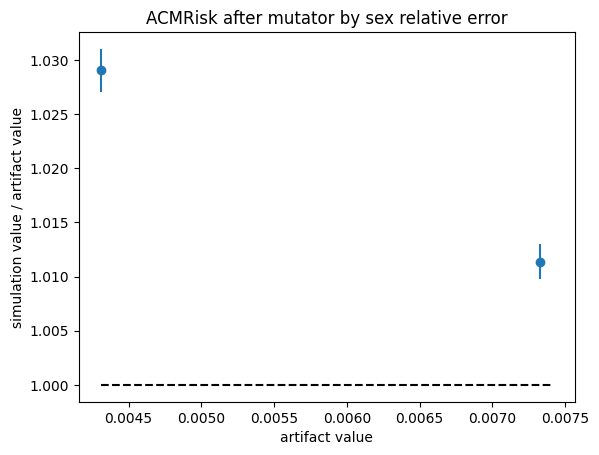

In [80]:
step_by_step_check_acmrisk(LATE_NEONATAL_AGE_START, LATE_NEONATAL_AGE_END)

### Check cause-specific mortality risks

In [81]:
# Check that our transfer above actually worked
assert (
    set(main_sim.get_population("all_causes.all_cause_mortality_risk.paf").loc[alive_idx].unique())
    <=
    set(acmrisk_pafs['value'].unique())
)

In [82]:
# Check that our transfer above actually worked
assert (
    set(main_sim_components['preterm_birth.neonatal_preterm_birth_with_rds'].lbwsg_acmr_paf(main_sim.get_population_index()).unique())
    <=
    set(preterm_csmr_pafs['value'].unique())
)

neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma
Targets


sex_of_child
Female    0.000370
Male      0.001022
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2615934.0,0.000398,0.001278,0.000087,0.000106,0.000154,0.000291,0.040087
Male,2748608.0,0.001106,0.003091,0.000228,0.000314,0.000468,0.000888,0.100956


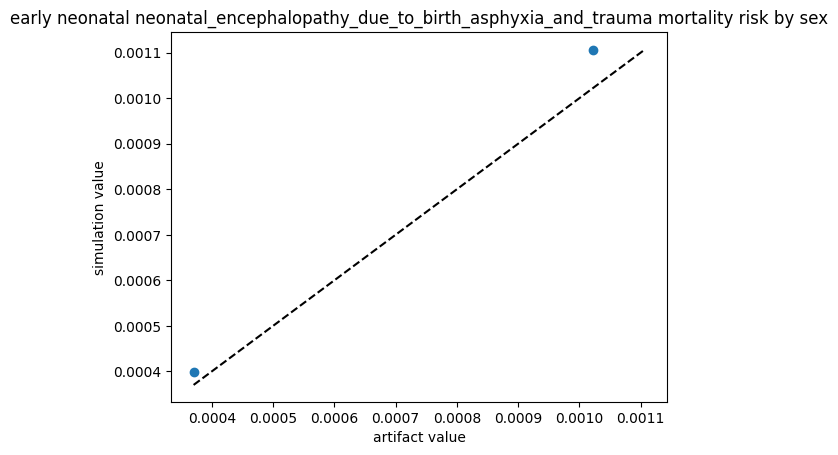

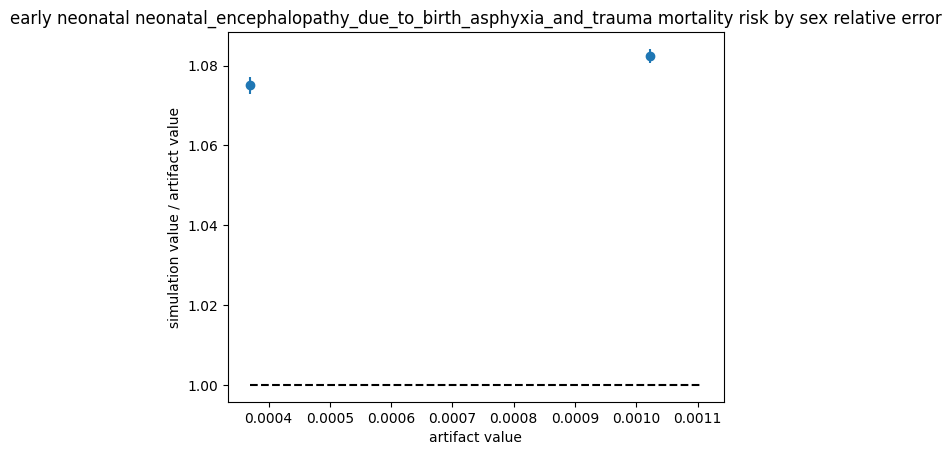

neonatal_sepsis_and_other_neonatal_infections
Targets


sex_of_child
Female    0.000716
Male      0.001788
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2615934.0,0.000698,0.002150,0.000160,0.000195,0.000280,0.000522,0.073432
Male,2748608.0,0.001746,0.004659,0.000379,0.000520,0.000768,0.001423,0.167324


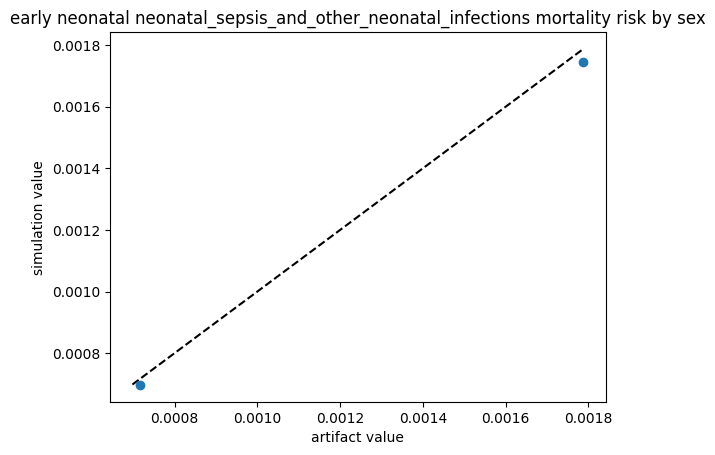

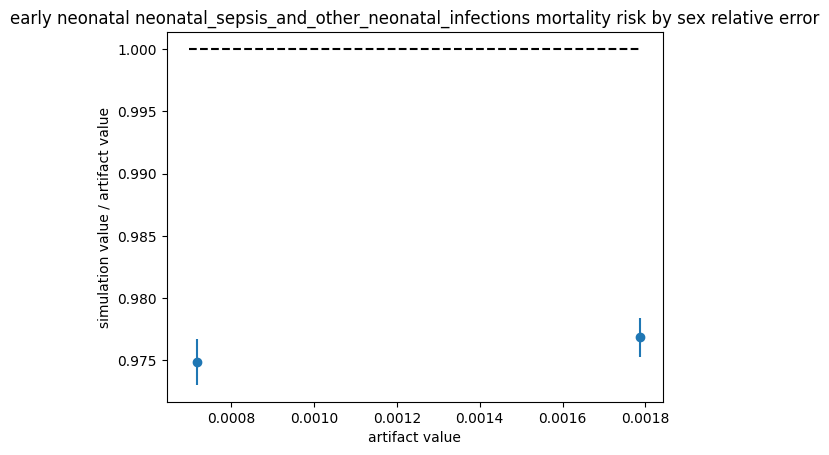

neonatal_preterm_birth
Targets


sex_of_child
Female    0.000492
Male      0.001178
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2615934.0,0.000411,0.002992,0.0,0.0,0.0,0.0,0.130863
Male,2748608.0,0.000984,0.005781,0.0,0.0,0.0,0.0,0.275538


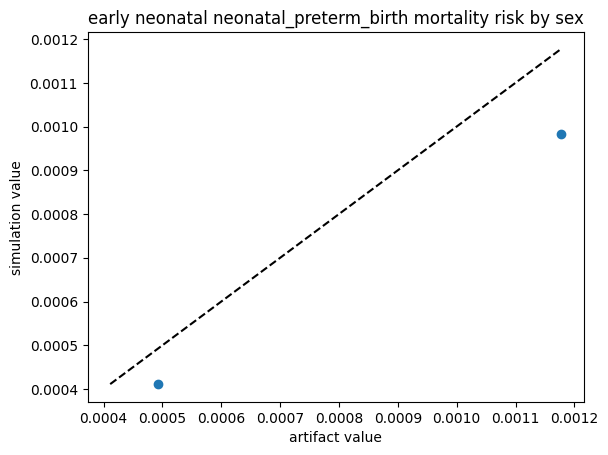

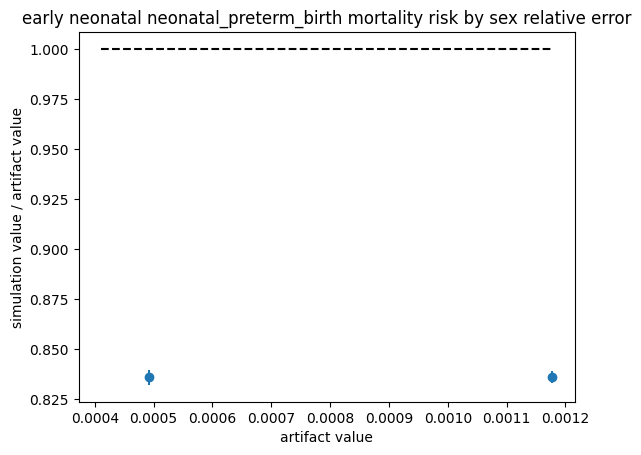

neonatal_preterm_birth_with_rds
Targets


sex_of_child
Female    0.000418
Male      0.001001
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2615934.0,0.000331,0.002495,0.0,0.0,0.0,0.0,0.112997
Male,2748608.0,0.000787,0.004784,0.0,0.0,0.0,0.0,0.237921


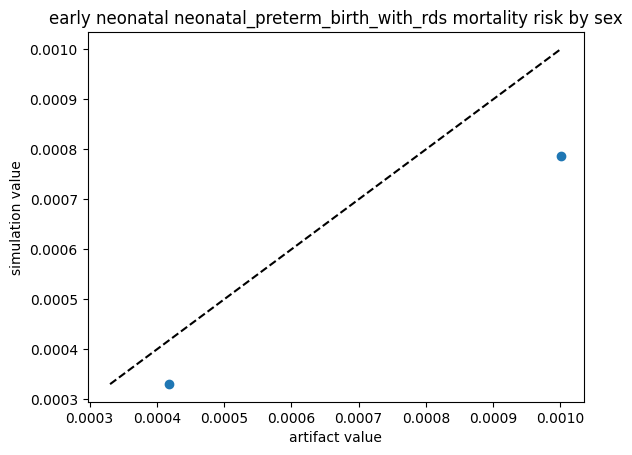

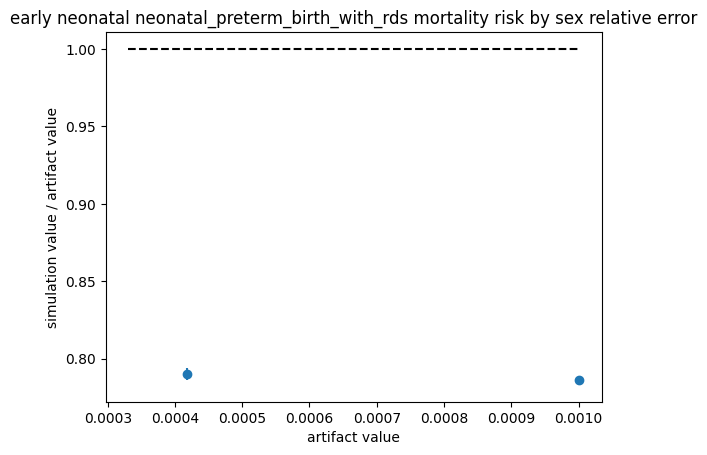

neonatal_preterm_birth_without_rds
Targets


sex_of_child
Female    0.000074
Male      0.000177
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2615934.0,0.000081,0.000546,0.0,0.0,0.0,0.0,0.017866
Male,2748608.0,0.000197,0.001104,0.0,0.0,0.0,0.0,0.037619


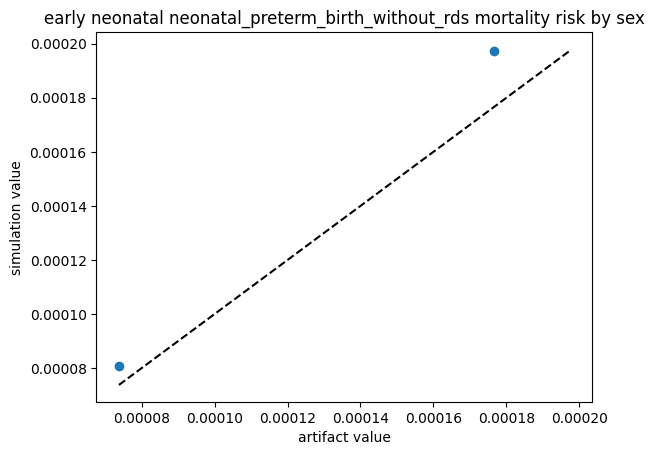

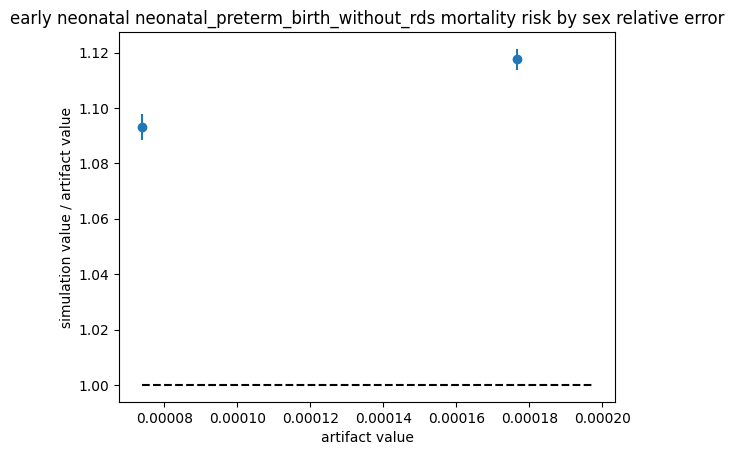

In [83]:
check_csmrisks(LATE_NEONATAL_AGE_START, LATE_NEONATAL_AGE_END)

#### Check frequency of negative other-causes mortality, and impact

This isn't the best check because it is only for a single draw and location. In the one I've chosen, this rarely happens, apparently.

In [84]:
csmrisk_pipeline_names = result = sorted({item for values in CAUSE_NAME_TO_CSMRISK_PIPELINES.values() for item in values})
csmrisk_pipeline_names

['neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma.csmr',
 'neonatal_preterm_birth_with_rds.csmr',
 'neonatal_preterm_birth_without_rds.csmr',
 'neonatal_sepsis_and_other_neonatal_infections.csmr']

In [85]:
total_csmrisk = 0

for pipeline_name in csmrisk_pipeline_names:
    total_csmrisk += (
        main_sim.get_population(pipeline_name).loc[alive_idx].rename('total_csmrisk')
    )

total_csmrisk

1          0.000607
3          0.001168
4          0.001087
5          0.012849
6          0.009641
             ...   
9999990    0.000449
9999995    0.000791
9999996    0.000333
9999997    0.020977
9999998    0.000439
Name: total_csmrisk, Length: 5364542, dtype: float64

In [86]:
total_csmrisk.describe()

count    5.364542e+06
mean     2.700813e-03
std      1.037003e-02
min      2.474800e-04
25%      4.447058e-04
50%      8.630207e-04
75%      1.870202e-03
max      5.438161e-01
Name: total_csmrisk, dtype: float64

In [87]:
(total_csmrisk > mortality_risk).mean()

0.0

In [88]:
# Expect CSMRisks to be underestimated by this amount as a result
(total_csmrisk - mortality_risk).clip(0).sum() / total_csmrisk.sum()

0.0

#### Check individual steps in calculation of cause-specific mortality risks

neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma
Initial cause-specific mortality risk


sex_of_child
Female    0.000370
Male      0.001022
Name: value, dtype: float64

After LBWSG:


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2615934.0,0.000398,0.001278,0.000087,0.000106,0.000154,0.000291,0.040087
Male,2748608.0,0.001106,0.003091,0.000228,0.000314,0.000468,0.000888,0.100956


Targets


sex_of_child
Female    0.000370
Male      0.001022
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2615934.0,0.000398,0.001278,0.000087,0.000106,0.000154,0.000291,0.040087
Male,2748608.0,0.001106,0.003091,0.000228,0.000314,0.000468,0.000888,0.100956


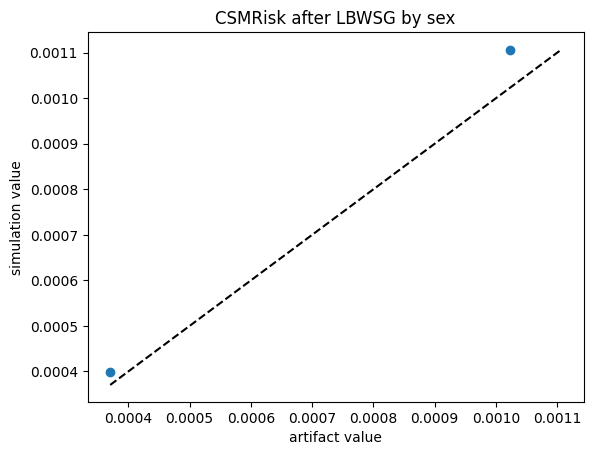

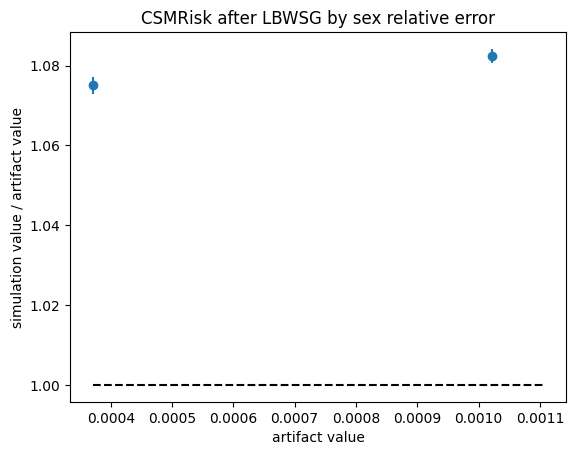

Mutators:


[]

neonatal_sepsis_and_other_neonatal_infections
Initial cause-specific mortality risk


sex_of_child
Female    0.000716
Male      0.001788
Name: value, dtype: float64

After LBWSG:


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2615934.0,0.000770,0.002471,0.000169,0.000205,0.000297,0.000562,0.077493
Male,2748608.0,0.001935,0.005406,0.000400,0.000550,0.000819,0.001552,0.176581


Targets


sex_of_child
Female    0.000716
Male      0.001788
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2615934.0,0.000770,0.002471,0.000169,0.000205,0.000297,0.000562,0.077493
Male,2748608.0,0.001935,0.005406,0.000400,0.000550,0.000819,0.001552,0.176581


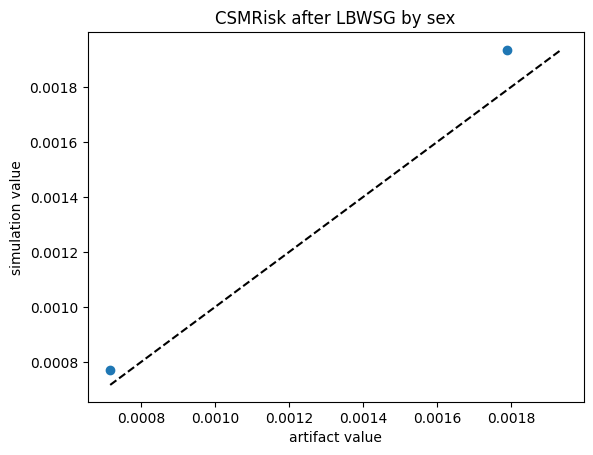

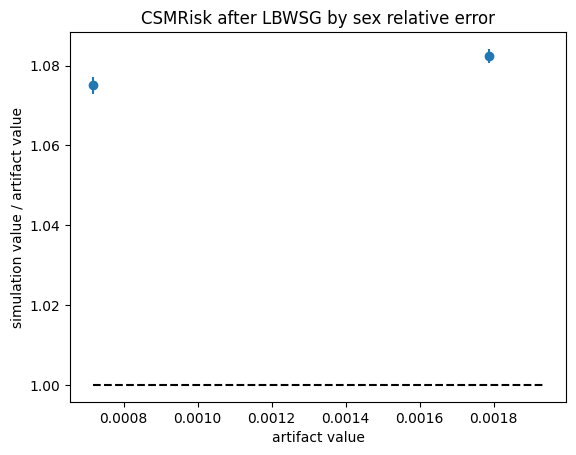

Mutators:


After <vivarium.framework.values.pipeline.ValueModifier object at 0x7f2f694be6d0>
Targets


sex_of_child
Female    0.000716
Male      0.001788
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2615934.0,0.000730,0.002342,0.000160,0.000195,0.000282,0.000533,0.073432
Male,2748608.0,0.001833,0.005123,0.000379,0.000521,0.000776,0.001471,0.167328


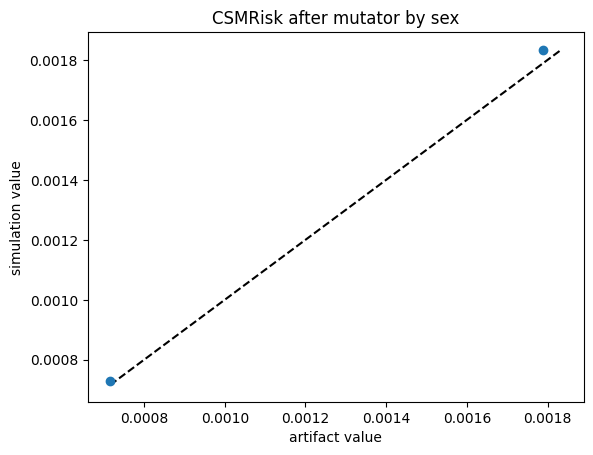

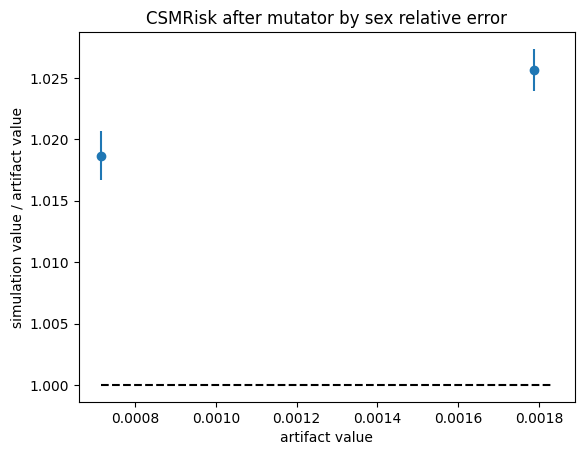

After <vivarium.framework.values.pipeline.ValueModifier object at 0x7f2f6963fb10>
Targets


sex_of_child
Female    0.000716
Male      0.001788
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2615934.0,0.000698,0.002150,0.000160,0.000195,0.000280,0.000522,0.073432
Male,2748608.0,0.001746,0.004659,0.000379,0.000520,0.000768,0.001423,0.167324


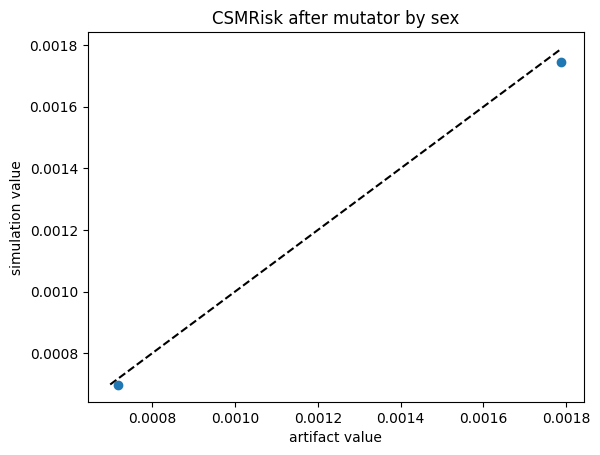

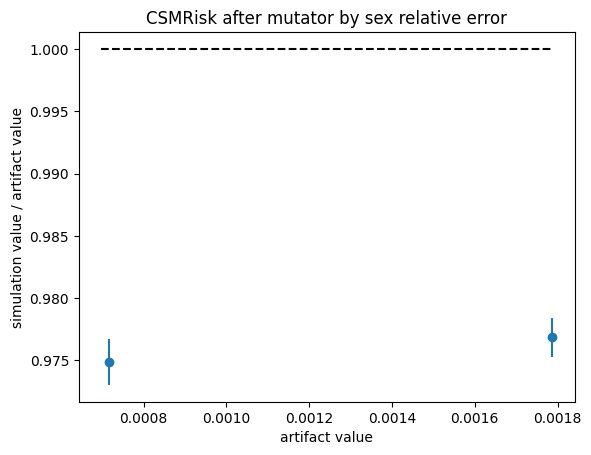

neonatal_preterm_birth_with_rds
Initial cause-specific mortality risk


sex_of_child
Female    0.000492
Male      0.001178
Name: value, dtype: float64

Preterm prevalence:


sex_of_child
Female    0.133338
Male      0.180006
Name: value, dtype: float64

 value 0.141457 is significantly greater than expected, bayes factor = inf
 value 0.189139 is significantly greater than expected, bayes factor = inf


sex_of_child
Female    0.000522
Male      0.001237
Name: value, dtype: float64

Targets


sex_of_child
Female    0.000492
Male      0.001178
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2615934.0,0.000522,0.001286,0.0,0.0,0.0,0.0,0.003690
Male,2748608.0,0.001237,0.002562,0.0,0.0,0.0,0.0,0.006541


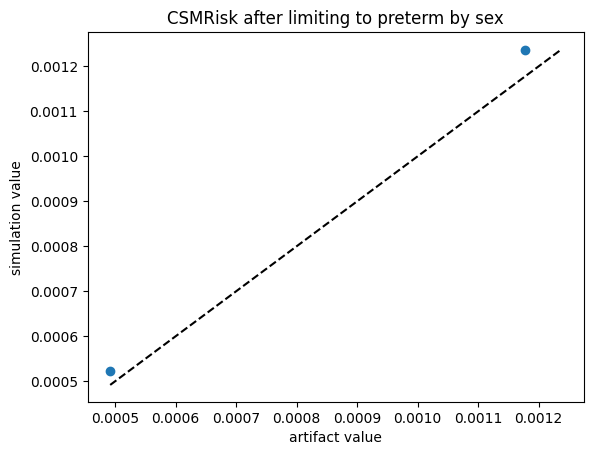

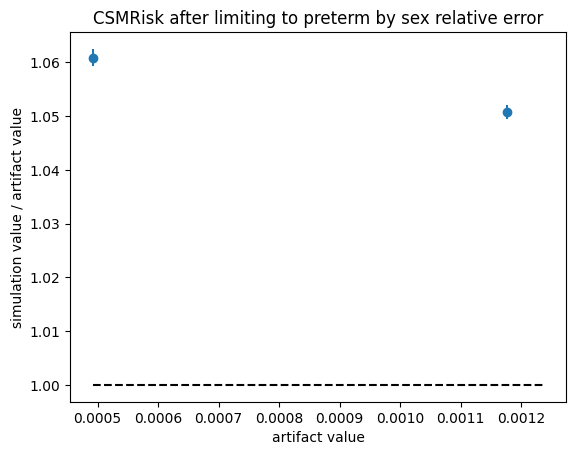

Targets


sex_of_child
Female    0.000418
Male      0.001001
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2615934.0,0.000444,0.001093,0.0,0.0,0.0,0.0,0.003137
Male,2748608.0,0.001052,0.002178,0.0,0.0,0.0,0.0,0.005560


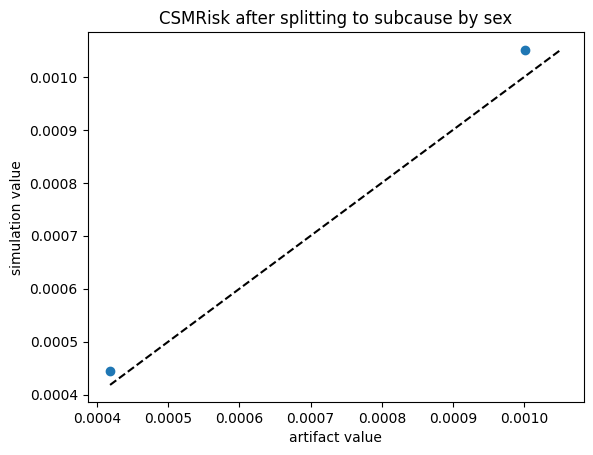

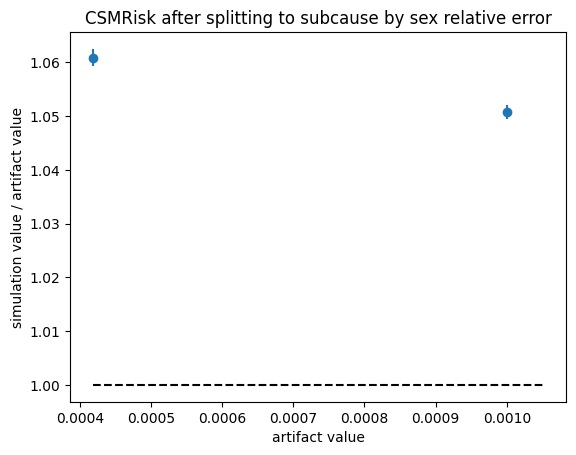

After LBWSG:


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2615934.0,0.000457,0.003094,0.0,0.0,0.0,0.0,0.101240
Male,2748608.0,0.001119,0.006258,0.0,0.0,0.0,0.0,0.213173


Targets


sex_of_child
Female    0.000418
Male      0.001001
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2615934.0,0.000457,0.003094,0.0,0.0,0.0,0.0,0.101240
Male,2748608.0,0.001119,0.006258,0.0,0.0,0.0,0.0,0.213173


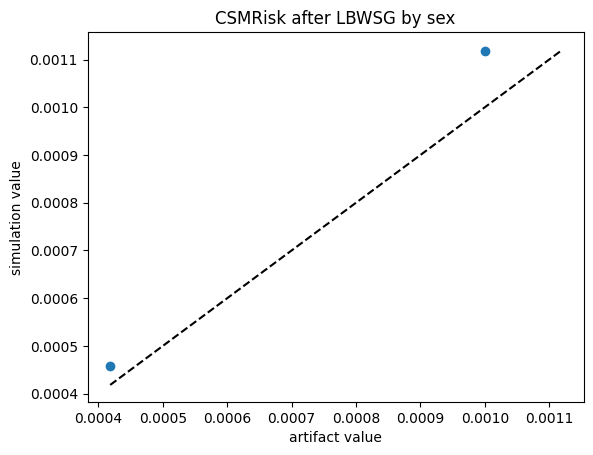

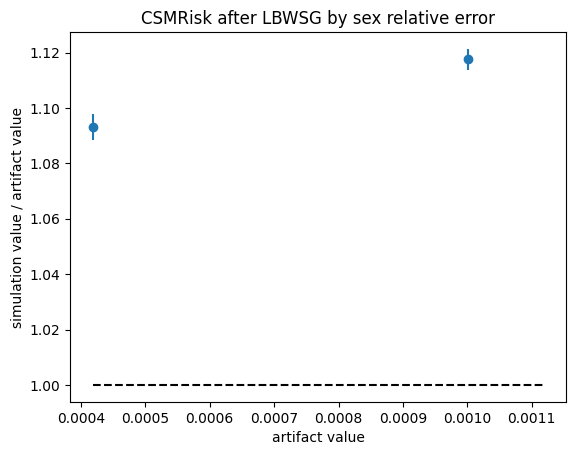

Mutators:


After <vivarium.framework.values.pipeline.ValueModifier object at 0x7f2f69325a10>
Targets


sex_of_child
Female    0.000418
Male      0.001001
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2615934.0,0.000331,0.002495,0.0,0.0,0.0,0.0,0.112997
Male,2748608.0,0.000787,0.004784,0.0,0.0,0.0,0.0,0.237921


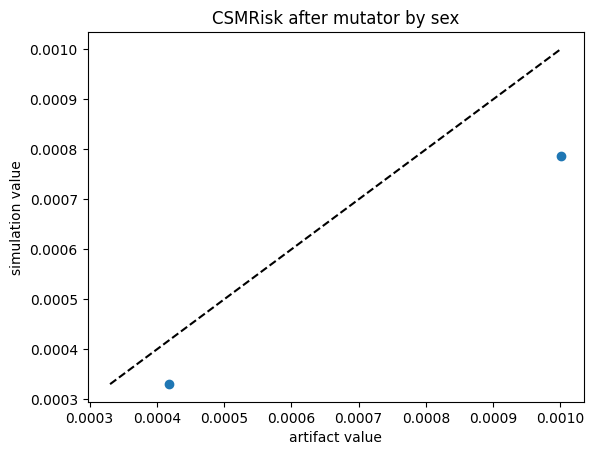

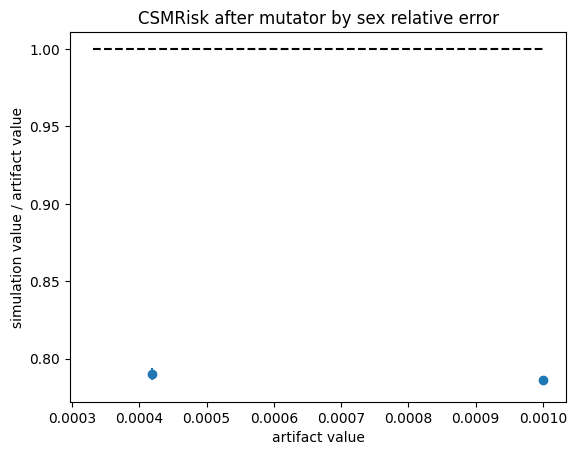

neonatal_preterm_birth_without_rds
Initial cause-specific mortality risk


sex_of_child
Female    0.000492
Male      0.001178
Name: value, dtype: float64

Preterm prevalence:


sex_of_child
Female    0.133338
Male      0.180006
Name: value, dtype: float64

 value 0.141457 is significantly greater than expected, bayes factor = inf
 value 0.189139 is significantly greater than expected, bayes factor = inf


sex_of_child
Female    0.000522
Male      0.001237
Name: value, dtype: float64

Targets


sex_of_child
Female    0.000492
Male      0.001178
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2615934.0,0.000522,0.001286,0.0,0.0,0.0,0.0,0.003690
Male,2748608.0,0.001237,0.002562,0.0,0.0,0.0,0.0,0.006541


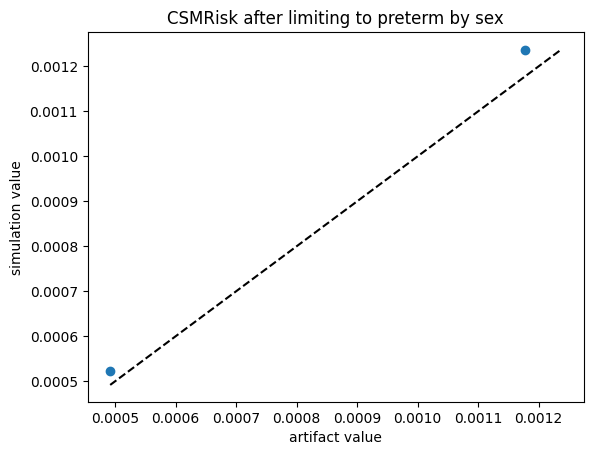

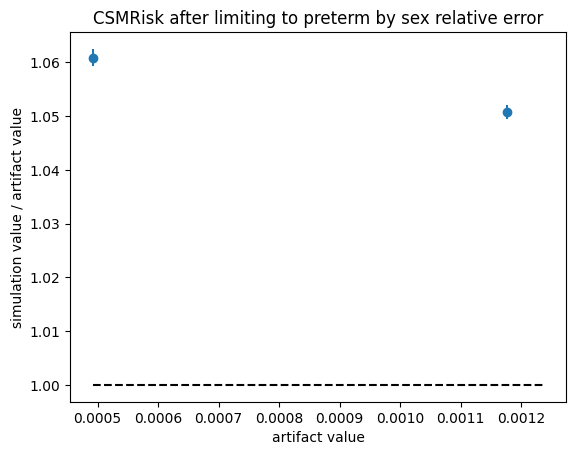

Targets


sex_of_child
Female    0.000074
Male      0.000177
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2615934.0,0.000078,0.000193,0.0,0.0,0.0,0.0,0.000554
Male,2748608.0,0.000186,0.000384,0.0,0.0,0.0,0.0,0.000981


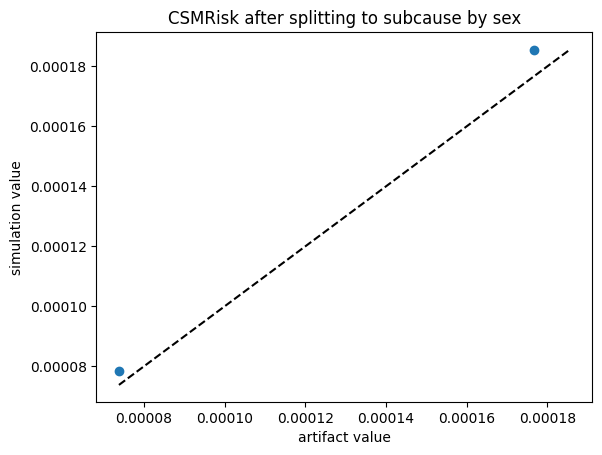

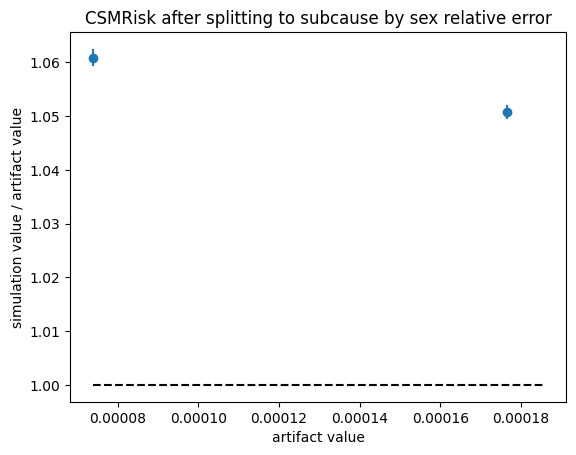

After LBWSG:


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2615934.0,0.000081,0.000546,0.0,0.0,0.0,0.0,0.017866
Male,2748608.0,0.000197,0.001104,0.0,0.0,0.0,0.0,0.037619


Targets


sex_of_child
Female    0.000074
Male      0.000177
Name: draw_60, dtype: float64

Summaries of observed values


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,2615934.0,0.000081,0.000546,0.0,0.0,0.0,0.0,0.017866
Male,2748608.0,0.000197,0.001104,0.0,0.0,0.0,0.0,0.037619


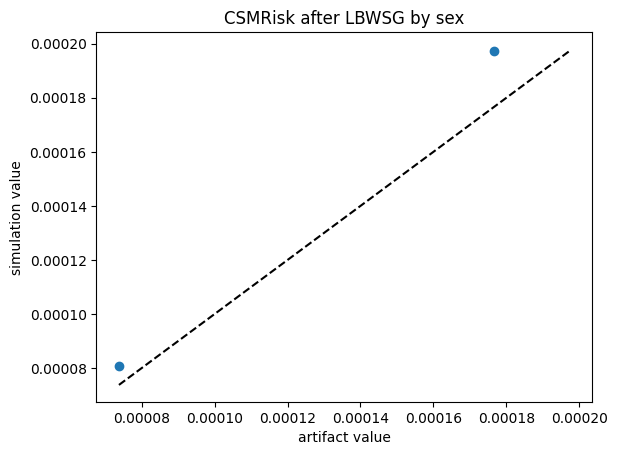

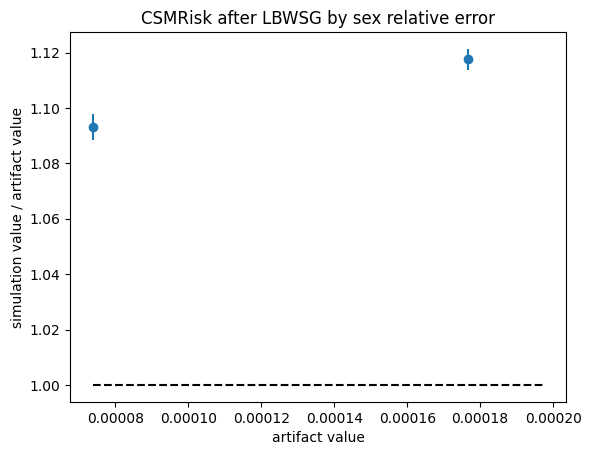

Mutators:


[]

In [89]:
for cause_name in NEONATAL_CAUSES:
    if cause_name == 'neonatal_preterm_birth':
        continue
    print(cause_name)
    step_by_step_check_csmrisk(cause_name, LATE_NEONATAL_AGE_START, LATE_NEONATAL_AGE_END)

In [90]:
assert not any_failures

AssertionError: 

In [ ]:
!date

Thu May 14 15:17:00 PDT 2026
